# URL Multiclass — Durcissement HGB : stabilité et recall malware

Ce notebook poursuit uniquement le candidat :

`HGB raw balanced`

sélectionné après la comparaison contrôlée entre :

- Logistic Regression V2 ;
- HistGradientBoosting ;
- ExtraTrees.

Le benchmark précédent a montré que `HistGradientBoostingClassifier` améliore nettement la performance moyenne et la détection phishing, mais présente deux limites :

1. une variabilité inter-folds plus élevée que LR-V2 ;
2. un recall malware OOF trop faible.

Résultats de référence HGB raw :

- macro-F1 CV : `0.860979 ± 0.067938` ;
- balanced accuracy CV : `0.858426` ;
- F1 phishing CV : `0.868059` ;
- recall phishing CV : `0.826859` ;
- macro-F1 OOF : `0.847563` ;
- F1 malware OOF : `0.814249` ;
- recall malware OOF : `0.707362` ;
- phishing → benign OOF : `16.80 %` ;
- malware → benign OOF : `22.04 %`.

L'objectif n'est plus de rechercher une nouvelle famille.

> Nous cherchons à conserver le gain phishing de HGB tout en améliorant la robustesse inter-groupes et le recall malware.

---

# Hypothèses testées

Nous étudions trois leviers seulement :

## 1. Régularisation structurelle

Réduire la complexité des arbres ou augmenter la taille minimale des feuilles peut réduire la sensibilité aux groupes particuliers.

## 2. Régularisation L2

Une pénalisation des valeurs de feuilles peut lisser les décisions et améliorer la stabilité.

## 3. Pondération malware légèrement renforcée

HGB présente une precision malware très élevée mais un recall plus faible.

Nous testons donc une pondération malware modérée afin de vérifier s'il est possible d'échanger une partie de cette marge de precision contre davantage de recall.

Aucune recherche exhaustive d'hyperparamètres n'est effectuée.

## 0. Protocole expérimental

Toutes les variantes utilisent :

- le même snapshot `2026-08-12-v1` ;
- le Feature Set technique `2.0.0` ;
- les 13 features **raw** ;
- la même quarantaine multi-label ;
- le même split externe 80/20 verrouillé ;
- les mêmes 5 folds internes `StratifiedGroupKFold` ;
- le seed `42`.

Le test externe n'est jamais utilisé pour sélectionner une variante.

Toutes les pondérations personnalisées sont calculées **uniquement à partir du train du fold**.

`early_stopping=False` reste imposé pour éviter une validation interne indépendante de nos `group_key`.

In [1]:
from __future__ import annotations

import os
import platform
import sys
import time
import warnings
from contextlib import contextmanager
from pathlib import Path

from dotenv import load_dotenv


def find_project_root() -> Path:
    current = Path.cwd().resolve()

    for candidate in (
        current,
        *current.parents,
    ):
        if (
            (candidate / "application").is_dir()
            and (candidate / "infrastructure").is_dir()
        ):
            return candidate

    raise RuntimeError(
        "Impossible de retrouver la racine du projet."
    )


PROJECT_ROOT = find_project_root()

load_dotenv(
    dotenv_path=PROJECT_ROOT / ".env",
    override=False,
)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(
        0,
        str(PROJECT_ROOT),
    )

if not os.environ.get(
    "INGESTION_DATABASE_URL"
):
    raise RuntimeError(
        "INGESTION_DATABASE_URL n'est pas définie."
    )

print("Project root: détecté")
print(
    "INGESTION_DATABASE_URL: définie "
    "(valeur masquée)"
)

Project root: détecté
INGESTION_DATABASE_URL: définie (valeur masquée)


In [2]:
try:
    import matplotlib
    import matplotlib.pyplot as plt
    import numpy as np
    import pandas as pd
    import sklearn
    import sqlalchemy

    from IPython.display import display
    from sqlalchemy import text

    from sklearn.ensemble import (
        HistGradientBoostingClassifier,
    )
    from sklearn.metrics import (
        accuracy_score,
        average_precision_score,
        balanced_accuracy_score,
        classification_report,
        cohen_kappa_score,
        confusion_matrix,
        ConfusionMatrixDisplay,
        f1_score,
        jaccard_score,
        log_loss,
        matthews_corrcoef,
        precision_score,
        recall_score,
        roc_auc_score,
        top_k_accuracy_score,
    )
    from sklearn.model_selection import (
        StratifiedGroupKFold,
    )
    from sklearn.preprocessing import (
        label_binarize,
    )
    from sklearn.utils.class_weight import (
        compute_sample_weight,
    )

    from infrastructure.persistence.sqlalchemy.engine import (
        create_ingestion_engine,
    )

except ImportError as exc:
    raise RuntimeError(
        "Une dépendance EDA/ML est manquante."
    ) from exc


pd.set_option(
    "display.max_columns",
    140,
)
pd.set_option(
    "display.max_rows",
    140,
)
pd.set_option(
    "display.width",
    220,
)

print("Python:", platform.python_version())
print("pandas:", pd.__version__)
print("numpy:", np.__version__)
print("matplotlib:", matplotlib.__version__)
print("scikit-learn:", sklearn.__version__)
print("SQLAlchemy:", sqlalchemy.__version__)

Python: 3.12.6
pandas: 2.2.3
numpy: 2.2.6
matplotlib: 3.10.0
scikit-learn: 1.6.1
SQLAlchemy: 2.0.51


## 1. Constantes et références

Aucune transformation `log1p` n'est utilisée.

Le benchmark précédent a montré des résultats strictement identiques entre HGB raw et HGB log1p. Nous conservons donc la représentation raw, plus simple.

In [3]:
RANDOM_SEED = 42

DATASET_NAME = (
    "url_multiclass_pool"
)
DATASET_VERSION = (
    "2026-08-12-v1"
)
EXPECTED_FEATURE_SET_VERSION = (
    "2.0.0"
)

LABEL_ORDER = [
    "benign",
    "phishing",
    "malware",
]

PROBABILITY_LABEL_ORDER = sorted(
    LABEL_ORDER
)

EXPECTED_LABELS = set(
    LABEL_ORDER
)

RAW_FEATURE_COLUMNS = [
    "url_length",
    "hostname_length",
    "dot_count",
    "hyphen_count",
    "digit_count",
    "special_char_count",
    "path_segment_count",
    "hostname_entropy",
    "mean_hostname_label_length",
    "path_to_url_length_ratio",
    "special_char_ratio",
    "path_length_special_char_ratio_product",
    "path_segment_count_special_char_ratio_product",
]

EXPECTED_POOL_ROWS = 155_818
EXPECTED_QUARANTINED_ROWS = 12_126
EXPECTED_SPLIT_READY_ROWS = 143_692

EXPECTED_POST_QUARANTINE_COUNTS = {
    "benign": 58_433,
    "phishing": 56_668,
    "malware": 28_591,
}

EXPECTED_EXTERNAL_TRAIN_COUNTS = {
    "benign": 46_599,
    "phishing": 43_475,
    "malware": 24_057,
}

EXPECTED_EXTERNAL_TEST_COUNTS = {
    "benign": 11_834,
    "phishing": 13_193,
    "malware": 4_534,
}

EXTERNAL_SPLIT_N_SPLITS = 5
INTERNAL_CV_N_SPLITS = 5

HGB_REFERENCE_RESULTS = {
    "cv_macro_f1_mean": 0.860979,
    "cv_macro_f1_std": 0.067938,
    "cv_balanced_accuracy_mean": 0.858426,
    "cv_phishing_f1_mean": 0.868059,
    "cv_phishing_recall_mean": 0.826859,
    "oof_macro_f1": 0.847563,
    "oof_f1_malware": 0.814249,
    "oof_recall_malware": 0.707362,
    "oof_phishing_to_benign": 0.168005,
    "oof_malware_to_benign": 0.220352,
}

LR_V2_REFERENCE = {
    "cv_macro_f1_mean": 0.815393,
    "cv_macro_f1_std": 0.027901,
    "oof_macro_f1": 0.819447,
    "oof_f1_malware": 0.825925,
    "oof_recall_malware": 0.807540,
    "oof_phishing_to_benign": 0.181415,
}

print("Seed:", RANDOM_SEED)
print("Features HGB:", len(RAW_FEATURE_COLUMNS))

Seed: 42
Features HGB: 13


# Partie I — Reconstruction de la population

## 2. Lecture PostgreSQL strictement read-only

Comme dans les notebooks précédents :

- aucune URL brute n'est chargée ;
- aucun hostname n'est chargé ;
- aucun hash n'est chargé ;
- `group_key` n'est jamais une feature ;
- aucune écriture DB n'est effectuée.

In [4]:
engine = create_ingestion_engine()


@contextmanager
def read_connection():
    with engine.connect() as connection:
        with connection.begin():
            connection.execute(
                text(
                    "SET TRANSACTION READ ONLY"
                )
            )
            yield connection


with read_connection() as connection:
    read_only_state = (
        connection.execute(
            text(
                """
                SELECT current_setting(
                    'transaction_read_only'
                )
                """
            )
        )
        .scalar_one()
    )

if read_only_state != "on":
    raise RuntimeError(
        "La transaction PostgreSQL "
        "n'est pas read-only."
    )

print(
    "Transaction PostgreSQL read-only confirmée."
)

Transaction PostgreSQL read-only confirmée.


In [5]:
snapshot_query = text(
    """
    SELECT
        id::text AS dataset_id,
        name,
        version,
        status,
        projection_version,
        feature_set_version,
        class_targets,
        label_mapping,
        created_at,
        frozen_at
    FROM ml.dataset_snapshot
    WHERE name = :dataset_name
      AND version = :dataset_version
    """
)

with read_connection() as connection:
    snapshot_df = pd.read_sql_query(
        snapshot_query,
        connection,
        params={
            "dataset_name": DATASET_NAME,
            "dataset_version": DATASET_VERSION,
        },
    )

if len(snapshot_df) != 1:
    raise RuntimeError(
        "Snapshot introuvable ou non unique."
    )

if (
    snapshot_df.loc[
        0,
        "feature_set_version",
    ]
    != EXPECTED_FEATURE_SET_VERSION
):
    raise RuntimeError(
        "Feature Set version incompatible."
    )

display(
    snapshot_df[
        [
            "name",
            "version",
            "status",
            "projection_version",
            "feature_set_version",
            "created_at",
            "frozen_at",
        ]
    ]
)

,name,version,status,projection_version,feature_set_version,created_at,frozen_at
0,url_multiclass_pool,2026-08-12-v1,draft,1.0.0,2.0.0,2026-08-12 16:57:36.639459+00:00,None


In [6]:
feature_sql = ",\n        ".join(
    (
        "vector.features ->> "
        f"'{feature}' AS {feature}"
    )
    for feature
    in RAW_FEATURE_COLUMNS
)

load_query = text(
    f"""
    SELECT
        member.sample_id::text
            AS sample_id,
        member.label_code,
        member.group_key,
        member.split,
        vector.feature_set_version,
        {feature_sql}
    FROM ml.dataset_snapshot AS dataset
    JOIN ml.dataset_member AS member
      ON member.dataset_id = dataset.id
    LEFT JOIN ml.url_feature_vector AS vector
      ON vector.sample_id = member.sample_id
     AND vector.feature_set_version
         = dataset.feature_set_version
    WHERE dataset.name = :dataset_name
      AND dataset.version = :dataset_version
    """
)

with read_connection() as connection:
    df = pd.read_sql_query(
        load_query,
        connection,
        params={
            "dataset_name": DATASET_NAME,
            "dataset_version": DATASET_VERSION,
        },
    )

print("Shape:", df.shape)

Shape: (155818, 18)


## 3. Sanity checks et quarantaine

Le benchmark est interrompu si la population ne reproduit pas exactement celle des expériences précédentes.

In [7]:
if len(df) != EXPECTED_POOL_ROWS:
    raise RuntimeError(
        "Le volume du snapshot a changé."
    )

if df[
    "sample_id"
].duplicated().any():
    raise RuntimeError(
        "sample_id dupliqué détecté."
    )

if df[
    "group_key"
].isna().any():
    raise RuntimeError(
        "group_key manquant détecté."
    )

if (
    set(
        df[
            "label_code"
        ].dropna().unique()
    )
    != EXPECTED_LABELS
):
    raise RuntimeError(
        "Labels inattendus."
    )

for feature in RAW_FEATURE_COLUMNS:
    converted = pd.to_numeric(
        df[
            feature
        ],
        errors="coerce",
    )

    if converted.isna().any():
        raise RuntimeError(
            f"{feature} contient une valeur "
            "manquante ou non numérique."
        )

    df[
        feature
    ] = converted


if not np.isfinite(
    df[
        RAW_FEATURE_COLUMNS
    ].to_numpy(
        dtype=float
    )
).all():
    raise RuntimeError(
        "Valeur numérique non finie détectée."
    )

print("✓ Pool source valide")

✓ Pool source valide


In [8]:
group_label_counts = (
    df.groupby(
        "group_key",
        observed=True,
    )[
        "label_code"
    ]
    .nunique()
)

shared_group_keys = (
    group_label_counts.index[
        group_label_counts > 1
    ]
)

shared_group_mask = (
    df[
        "group_key"
    ].isin(
        shared_group_keys
    )
)

if (
    int(
        shared_group_mask.sum()
    )
    != EXPECTED_QUARANTINED_ROWS
):
    raise RuntimeError(
        "La quarantaine a changé."
    )

split_df = (
    df.loc[
        ~shared_group_mask
    ]
    .copy()
    .reset_index(
        drop=True
    )
)

if len(split_df) != EXPECTED_SPLIT_READY_ROWS:
    raise RuntimeError(
        "Population post-quarantaine inattendue."
    )

post_counts = (
    split_df[
        "label_code"
    ]
    .value_counts()
    .reindex(
        LABEL_ORDER,
        fill_value=0,
    )
)

expected_counts = (
    pd.Series(
        EXPECTED_POST_QUARANTINE_COUNTS
    )
    .reindex(
        LABEL_ORDER
    )
)

if not post_counts.equals(
    expected_counts
):
    raise RuntimeError(
        "Volumes post-quarantaine inattendus."
    )

remaining_multilabel = int(
    (
        split_df
        .groupby(
            "group_key",
            observed=True,
        )[
            "label_code"
        ]
        .nunique()
        > 1
    ).sum()
)

if remaining_multilabel != 0:
    raise RuntimeError(
        "Un groupe multi-label subsiste."
    )

print(
    "✓ Population post-quarantaine:",
    len(split_df),
)
display(
    post_counts
    .rename("rows")
    .to_frame()
)

✓ Population post-quarantaine: 143692


,rows
label_code,
benign,58433
phishing,56668
malware,28591


In [9]:
engine.dispose()

print(
    "Engine PostgreSQL libéré."
)

Engine PostgreSQL libéré.


# Partie II — Split externe verrouillé et folds internes

## 4. Reconstruire le split externe 80/20 historique

Le test externe est reconstruit uniquement pour figer la frontière expérimentale.

Il n'est jamais utilisé dans la sélection HGB.

In [10]:
def build_reference_external_split(
    frame: pd.DataFrame,
):
    stable_frame = (
        frame
        .sort_values(
            [
                "label_code",
                "group_key",
                "sample_id",
            ],
            kind="mergesort",
        )
        .reset_index(
            drop=True
        )
    )

    y = stable_frame[
        "label_code"
    ].to_numpy()

    groups = stable_frame[
        "group_key"
    ].to_numpy()

    class_totals = (
        stable_frame[
            "label_code"
        ]
        .value_counts()
        .reindex(
            LABEL_ORDER,
            fill_value=0,
        )
    )

    splitter = StratifiedGroupKFold(
        n_splits=EXTERNAL_SPLIT_N_SPLITS,
        shuffle=True,
        random_state=RANDOM_SEED,
    )

    placeholder = np.zeros(
        (
            len(stable_frame),
            1,
        ),
        dtype=np.uint8,
    )

    target_fraction = (
        1.0
        / EXTERNAL_SPLIT_N_SPLITS
    )

    candidates = []
    candidate_indices = {}

    for fold_id, (
        train_idx,
        test_idx,
    ) in enumerate(
        splitter.split(
            placeholder,
            y,
            groups,
        )
    ):
        test_counts = (
            stable_frame
            .iloc[
                test_idx
            ][
                "label_code"
            ]
            .value_counts()
            .reindex(
                LABEL_ORDER,
                fill_value=0,
            )
        )

        deviations = (
            (
                test_counts
                / class_totals
            )
            - target_fraction
        ).abs()

        candidates.append(
            {
                "fold_id": fold_id,
                "max_abs_class_deviation": float(
                    deviations.max()
                ),
                "mean_abs_class_deviation": float(
                    deviations.mean()
                ),
                "test_rows": int(
                    len(test_idx)
                ),
            }
        )

        candidate_indices[
            fold_id
        ] = (
            train_idx,
            test_idx,
        )

    quality = (
        pd.DataFrame(
            candidates
        )
        .sort_values(
            [
                "max_abs_class_deviation",
                "mean_abs_class_deviation",
                "fold_id",
            ]
        )
        .reset_index(
            drop=True
        )
    )

    selected_fold = int(
        quality.loc[
            0,
            "fold_id",
        ]
    )

    (
        train_idx,
        test_idx,
    ) = candidate_indices[
        selected_fold
    ]

    return (
        stable_frame
        .iloc[
            train_idx
        ]
        .copy()
        .reset_index(
            drop=True
        ),
        stable_frame
        .iloc[
            test_idx
        ]
        .copy()
        .reset_index(
            drop=True
        ),
        quality,
    )


external_train_df, external_test_df, external_split_quality = (
    build_reference_external_split(
        split_df
    )
)

display(
    external_split_quality
)

,fold_id,max_abs_class_deviation,mean_abs_class_deviation,test_rows
0,3,0.041419,0.025584,29561
1,1,0.045962,0.016544,26339
2,0,0.072023,0.031086,32666
3,4,0.091364,0.035890,25359
4,2,0.148501,0.070863,29767


In [11]:
train_counts = (
    external_train_df[
        "label_code"
    ]
    .value_counts()
    .reindex(
        LABEL_ORDER,
        fill_value=0,
    )
)

test_counts = (
    external_test_df[
        "label_code"
    ]
    .value_counts()
    .reindex(
        LABEL_ORDER,
        fill_value=0,
    )
)

if not train_counts.equals(
    pd.Series(
        EXPECTED_EXTERNAL_TRAIN_COUNTS
    ).reindex(
        LABEL_ORDER
    )
):
    raise RuntimeError(
        "Train externe différent du split historique."
    )

if not test_counts.equals(
    pd.Series(
        EXPECTED_EXTERNAL_TEST_COUNTS
    ).reindex(
        LABEL_ORDER
    )
):
    raise RuntimeError(
        "Test externe différent du split historique."
    )

group_overlap = len(
    set(
        external_train_df[
            "group_key"
        ].unique()
    )
    & set(
        external_test_df[
            "group_key"
        ].unique()
    )
)

if group_overlap != 0:
    raise RuntimeError(
        "Fuite de group_key dans le split externe."
    )

print(
    "✓ Train externe:",
    len(external_train_df),
)
print(
    "✓ Test verrouillé:",
    len(external_test_df),
)

✓ Train externe: 114131
✓ Test verrouillé: 29561


## 5. Construire les mêmes 5 folds internes

Toutes les variantes HGB utilisent exactement les mêmes folds.

Cette comparaison appariée réduit le risque d'attribuer à un hyperparamètre un effet qui provient simplement d'un split différent.

In [12]:
cv_source_df = (
    external_train_df
    .sort_values(
        [
            "label_code",
            "group_key",
            "sample_id",
        ],
        kind="mergesort",
    )
    .reset_index(
        drop=True
    )
)

cv_y = (
    cv_source_df[
        "label_code"
    ].to_numpy()
)

cv_groups = (
    cv_source_df[
        "group_key"
    ].to_numpy()
)

cv_splitter = StratifiedGroupKFold(
    n_splits=INTERNAL_CV_N_SPLITS,
    shuffle=True,
    random_state=RANDOM_SEED,
)

placeholder = np.zeros(
    (
        len(cv_source_df),
        1,
    ),
    dtype=np.uint8,
)

cv_folds = []

for fold_id, (
    train_idx,
    validation_idx,
) in enumerate(
    cv_splitter.split(
        placeholder,
        cv_y,
        cv_groups,
    )
):
    train_groups = set(
        cv_source_df
        .iloc[
            train_idx
        ][
            "group_key"
        ]
        .unique()
    )

    validation_groups = set(
        cv_source_df
        .iloc[
            validation_idx
        ][
            "group_key"
        ]
        .unique()
    )

    if (
        train_groups
        & validation_groups
    ):
        raise RuntimeError(
            f"Fuite group_key fold {fold_id}."
        )

    cv_folds.append(
        (
            fold_id,
            train_idx,
            validation_idx,
        )
    )

print(
    "Folds internes:",
    len(cv_folds),
)

Folds internes: 5


In [13]:
fold_audit_rows = []

for (
    fold_id,
    train_idx,
    validation_idx,
) in cv_folds:
    train_part = (
        cv_source_df
        .iloc[
            train_idx
        ]
    )

    validation_part = (
        cv_source_df
        .iloc[
            validation_idx
        ]
    )

    validation_counts = (
        validation_part[
            "label_code"
        ]
        .value_counts()
        .reindex(
            LABEL_ORDER,
            fill_value=0,
        )
    )

    fold_audit_rows.append(
        {
            "fold_id": fold_id,
            "train_rows": int(
                len(train_part)
            ),
            "validation_rows": int(
                len(validation_part)
            ),
            "train_groups": int(
                train_part[
                    "group_key"
                ].nunique()
            ),
            "validation_groups": int(
                validation_part[
                    "group_key"
                ].nunique()
            ),
            "validation_benign": int(
                validation_counts[
                    "benign"
                ]
            ),
            "validation_phishing": int(
                validation_counts[
                    "phishing"
                ]
            ),
            "validation_malware": int(
                validation_counts[
                    "malware"
                ]
            ),
        }
    )

fold_audit_df = (
    pd.DataFrame(
        fold_audit_rows
    )
    .set_index(
        "fold_id"
    )
)

display(
    fold_audit_df
)

,train_rows,validation_rows,train_groups,validation_groups,validation_benign,validation_phishing,validation_malware
fold_id,,,,,,,
0,94034,20097,55384,12459,8598,5019,6480
1,92666,21465,54010,13833,9537,9338,2590
2,92655,21476,53986,13857,9484,8244,3748
3,85359,28772,53992,13851,9445,10772,8555
4,91810,22321,54000,13843,9535,10102,2684


# Partie III — Variantes HGB ciblées

## 6. Matrice d'expériences

Nous limitons volontairement le benchmark à quelques variantes interprétables.

| Code | But |
|---|---|
| `HGB_REF` | reproduire Candidate V3 actuelle |
| `HGB_LEAVES_15` | réduire la complexité structurelle |
| `HGB_MINLEAF_50` | lisser les feuilles |
| `HGB_L2_1` | régulariser les valeurs des feuilles |
| `HGB_REG_COMBINED` | combiner une régularisation modérée |
| `HGB_SLOW_005_200` | learning rate plus faible, davantage d'itérations |
| `HGB_MALWARE_X1_25` | augmenter modérément le coût des erreurs malware |

Nous ne faisons pas de GridSearch exhaustive.

Le but est d'identifier **quel levier corrige réellement la faiblesse malware/stabilité**.

In [14]:
HGB_CONFIGS = {
    "HGB_REF": {
        "params": {
            "learning_rate": 0.1,
            "max_iter": 100,
            "max_leaf_nodes": 31,
            "min_samples_leaf": 20,
            "l2_regularization": 0.0,
        },
        "class_weight": "balanced",
        "malware_weight_multiplier": 1.0,
    },

    "HGB_LEAVES_15": {
        "params": {
            "learning_rate": 0.1,
            "max_iter": 100,
            "max_leaf_nodes": 15,
            "min_samples_leaf": 20,
            "l2_regularization": 0.0,
        },
        "class_weight": "balanced",
        "malware_weight_multiplier": 1.0,
    },

    "HGB_MINLEAF_50": {
        "params": {
            "learning_rate": 0.1,
            "max_iter": 100,
            "max_leaf_nodes": 31,
            "min_samples_leaf": 50,
            "l2_regularization": 0.0,
        },
        "class_weight": "balanced",
        "malware_weight_multiplier": 1.0,
    },

    "HGB_L2_1": {
        "params": {
            "learning_rate": 0.1,
            "max_iter": 100,
            "max_leaf_nodes": 31,
            "min_samples_leaf": 20,
            "l2_regularization": 1.0,
        },
        "class_weight": "balanced",
        "malware_weight_multiplier": 1.0,
    },

    "HGB_REG_COMBINED": {
        "params": {
            "learning_rate": 0.1,
            "max_iter": 100,
            "max_leaf_nodes": 15,
            "min_samples_leaf": 50,
            "l2_regularization": 1.0,
        },
        "class_weight": "balanced",
        "malware_weight_multiplier": 1.0,
    },

    "HGB_SLOW_005_200": {
        "params": {
            "learning_rate": 0.05,
            "max_iter": 200,
            "max_leaf_nodes": 31,
            "min_samples_leaf": 20,
            "l2_regularization": 0.0,
        },
        "class_weight": "balanced",
        "malware_weight_multiplier": 1.0,
    },

    "HGB_MALWARE_X1_25": {
        "params": {
            "learning_rate": 0.1,
            "max_iter": 100,
            "max_leaf_nodes": 31,
            "min_samples_leaf": 20,
            "l2_regularization": 0.0,
        },
        "class_weight": None,
        "malware_weight_multiplier": 1.25,
    },
}


def build_hgb(
    config: dict,
):
    return HistGradientBoostingClassifier(
        loss="log_loss",
        class_weight=(
            config[
                "class_weight"
            ]
        ),
        early_stopping=False,
        random_state=RANDOM_SEED,
        **config[
            "params"
        ],
    )


config_rows = []

for name, config in (
    HGB_CONFIGS.items()
):
    config_rows.append(
        {
            "configuration": name,
            **config[
                "params"
            ],
            "class_weight": (
                config[
                    "class_weight"
                ]
            ),
            "malware_weight_multiplier": (
                config[
                    "malware_weight_multiplier"
                ]
            ),
        }
    )

display(
    pd.DataFrame(
        config_rows
    )
    .set_index(
        "configuration"
    )
)

,learning_rate,max_iter,max_leaf_nodes,min_samples_leaf,l2_regularization,class_weight,malware_weight_multiplier
configuration,,,,,,,
HGB_REF,0.10,100,31,20,0.0,balanced,1.00
HGB_LEAVES_15,0.10,100,15,20,0.0,balanced,1.00
HGB_MINLEAF_50,0.10,100,31,50,0.0,balanced,1.00
HGB_L2_1,0.10,100,31,20,1.0,balanced,1.00
HGB_REG_COMBINED,0.10,100,15,50,1.0,balanced,1.00
HGB_SLOW_005_200,0.05,200,31,20,0.0,balanced,1.00
HGB_MALWARE_X1_25,0.10,100,31,20,0.0,None,1.25


## 7. Pondération malware renforcée

La variante `HGB_MALWARE_X1_25` ne combine pas arbitrairement deux mécanismes de weighting.

Pour chaque fold :

1. `compute_sample_weight("balanced", y_train)` calcule les poids équilibrés à partir **du train du fold uniquement** ;
2. le poids des observations malware est multiplié par `1.25` ;
3. ces poids sont transmis à `fit(sample_weight=...)`.

Cela permet de tester une augmentation modérée du coût des faux négatifs malware sans utiliser la validation pour calculer les poids.

In [15]:
def build_fold_sample_weight(
    y_train: pd.Series,
    *,
    malware_multiplier: float,
):
    if (
        malware_multiplier
        == 1.0
    ):
        return None

    weights = compute_sample_weight(
        class_weight="balanced",
        y=y_train,
    ).astype(
        float
    )

    malware_mask = (
        y_train
        .to_numpy()
        == "malware"
    )

    weights[
        malware_mask
    ] *= malware_multiplier

    if not np.isfinite(
        weights
    ).all():
        raise RuntimeError(
            "Sample weights non finis."
        )

    if np.any(
        weights <= 0
    ):
        raise RuntimeError(
            "Sample weights non positifs."
        )

    return weights

# Partie IV — Métriques communes

## 8. Critères prioritaires

Cette phase ne cherche pas uniquement le macro-F1 maximum.

Une variante est intéressante si elle améliore le compromis suivant :

### Global

- macro-F1 moyen ;
- balanced accuracy ;
- stabilité inter-folds.

### Phishing

- F1 ;
- recall ;
- `phishing → benign`.

### Malware

- F1 ;
- recall ;
- `malware → benign`.

### Probabilités

- log-loss ;
- ROC-AUC ;
- Average Precision ;
- Brier multiclasses.

Nous cherchons en particulier à rapprocher le recall malware de LR-V2 sans perdre le gain phishing de HGB.

In [16]:
def aligned_probabilities(
    model,
    X: pd.DataFrame,
):
    raw_probabilities = (
        model.predict_proba(
            X
        )
    )

    model_classes = list(
        model.classes_
    )

    indices = [
        model_classes.index(
            label
        )
        for label
        in PROBABILITY_LABEL_ORDER
    ]

    probabilities = (
        raw_probabilities[
            :,
            indices,
        ]
    )

    if not np.isfinite(
        probabilities
    ).all():
        raise RuntimeError(
            "Probabilités non finies."
        )

    return probabilities


def multiclass_brier_score(
    y_true,
    probabilities,
):
    y_binary = label_binarize(
        y_true,
        classes=PROBABILITY_LABEL_ORDER,
    )

    return float(
        np.mean(
            np.sum(
                (
                    probabilities
                    - y_binary
                )
                ** 2,
                axis=1,
            )
        )
    )


def global_metrics(
    y_true,
    y_pred,
    probabilities,
):
    y_binary = label_binarize(
        y_true,
        classes=PROBABILITY_LABEL_ORDER,
    )

    return {
        "accuracy": accuracy_score(
            y_true,
            y_pred,
        ),
        "balanced_accuracy": (
            balanced_accuracy_score(
                y_true,
                y_pred,
            )
        ),
        "precision_macro": precision_score(
            y_true,
            y_pred,
            average="macro",
            zero_division=0,
        ),
        "recall_macro": recall_score(
            y_true,
            y_pred,
            average="macro",
            zero_division=0,
        ),
        "f1_macro": f1_score(
            y_true,
            y_pred,
            average="macro",
            zero_division=0,
        ),
        "f1_weighted": f1_score(
            y_true,
            y_pred,
            average="weighted",
            zero_division=0,
        ),
        "mcc": matthews_corrcoef(
            y_true,
            y_pred,
        ),
        "cohen_kappa": cohen_kappa_score(
            y_true,
            y_pred,
        ),
        "jaccard_macro": jaccard_score(
            y_true,
            y_pred,
            average="macro",
            zero_division=0,
        ),
        "log_loss": log_loss(
            y_true,
            probabilities,
            labels=PROBABILITY_LABEL_ORDER,
        ),
        "roc_auc_ovr_macro": roc_auc_score(
            y_true,
            probabilities,
            labels=PROBABILITY_LABEL_ORDER,
            multi_class="ovr",
            average="macro",
        ),
        "average_precision_macro": (
            average_precision_score(
                y_binary,
                probabilities,
                average="macro",
            )
        ),
        "top2_accuracy": top_k_accuracy_score(
            y_true,
            probabilities,
            k=2,
            labels=PROBABILITY_LABEL_ORDER,
        ),
        "multiclass_brier": (
            multiclass_brier_score(
                y_true,
                probabilities,
            )
        ),
    }


def per_class_metrics(
    y_true,
    y_pred,
):
    report = classification_report(
        y_true,
        y_pred,
        labels=LABEL_ORDER,
        output_dict=True,
        zero_division=0,
    )

    matrix = confusion_matrix(
        y_true,
        y_pred,
        labels=LABEL_ORDER,
    )

    total = int(
        matrix.sum()
    )

    rows = []

    for index, label in enumerate(
        LABEL_ORDER
    ):
        tp = int(
            matrix[
                index,
                index,
            ]
        )

        fn = int(
            matrix[
                index,
                :
            ].sum()
            - tp
        )

        fp = int(
            matrix[
                :,
                index
            ].sum()
            - tp
        )

        tn = int(
            total
            - tp
            - fn
            - fp
        )

        rows.append(
            {
                "label_code": label,
                "precision": float(
                    report[
                        label
                    ][
                        "precision"
                    ]
                ),
                "recall": float(
                    report[
                        label
                    ][
                        "recall"
                    ]
                ),
                "f1": float(
                    report[
                        label
                    ][
                        "f1-score"
                    ]
                ),
                "support": int(
                    report[
                        label
                    ][
                        "support"
                    ]
                ),
                "specificity": (
                    tn
                    / (
                        tn
                        + fp
                    )
                    if (
                        tn
                        + fp
                    )
                    > 0
                    else np.nan
                ),
                "false_positive_rate": (
                    fp
                    / (
                        fp
                        + tn
                    )
                    if (
                        fp
                        + tn
                    )
                    > 0
                    else np.nan
                ),
                "false_negative_rate": (
                    fn
                    / (
                        fn
                        + tp
                    )
                    if (
                        fn
                        + tp
                    )
                    > 0
                    else np.nan
                ),
            }
        )

    return (
        pd.DataFrame(
            rows
        )
        .set_index(
            "label_code"
        )
    )

# Partie V — Exécution du benchmark ciblé

## 9. Entraînement fold par fold

Chaque variante est recréée depuis zéro pour chaque fold.

Les modèles de CV ne sont pas sauvegardés.

Ils servent uniquement à sélectionner la meilleure configuration HGB.

In [17]:
fold_metric_rows = []
fold_class_metric_rows = []
runtime_rows = []

oof_predictions = {}
oof_probabilities = {}

for (
    config_name,
    config,
) in HGB_CONFIGS.items():

    oof_pred = np.empty(
        len(cv_source_df),
        dtype=object,
    )

    oof_proba = np.full(
        (
            len(cv_source_df),
            len(
                PROBABILITY_LABEL_ORDER
            ),
        ),
        np.nan,
        dtype=float,
    )

    for (
        fold_id,
        train_idx,
        validation_idx,
    ) in cv_folds:

        train_part = (
            cv_source_df
            .iloc[
                train_idx
            ]
        )

        validation_part = (
            cv_source_df
            .iloc[
                validation_idx
            ]
        )

        X_train = (
            train_part[
                RAW_FEATURE_COLUMNS
            ]
            .astype(float)
        )

        y_train = (
            train_part[
                "label_code"
            ]
        )

        X_validation = (
            validation_part[
                RAW_FEATURE_COLUMNS
            ]
            .astype(float)
        )

        y_validation = (
            validation_part[
                "label_code"
            ]
        )

        sample_weight = (
            build_fold_sample_weight(
                y_train,
                malware_multiplier=(
                    config[
                        "malware_weight_multiplier"
                    ]
                ),
            )
        )

        model = build_hgb(
            config
        )

        fit_started_at = (
            time.perf_counter()
        )

        if sample_weight is None:
            model.fit(
                X_train,
                y_train,
            )
        else:
            model.fit(
                X_train,
                y_train,
                sample_weight=sample_weight,
            )

        fit_seconds = (
            time.perf_counter()
            - fit_started_at
        )

        inference_started_at = (
            time.perf_counter()
        )

        validation_pred = (
            model.predict(
                X_validation
            )
        )

        validation_proba = (
            aligned_probabilities(
                model,
                X_validation,
            )
        )

        inference_seconds = (
            time.perf_counter()
            - inference_started_at
        )

        oof_pred[
            validation_idx
        ] = validation_pred

        oof_proba[
            validation_idx,
            :
        ] = validation_proba

        fold_metrics = global_metrics(
            y_validation,
            validation_pred,
            validation_proba,
        )

        fold_metric_rows.append(
            {
                "configuration": config_name,
                "fold_id": fold_id,
                **{
                    key: float(value)
                    for key, value
                    in fold_metrics.items()
                },
            }
        )

        class_metrics = (
            per_class_metrics(
                y_validation,
                validation_pred,
            )
        )

        for label, row in (
            class_metrics.iterrows()
        ):
            fold_class_metric_rows.append(
                {
                    "configuration": config_name,
                    "fold_id": fold_id,
                    "label_code": label,
                    **{
                        key: float(value)
                        for key, value
                        in row.items()
                    },
                }
            )

        runtime_rows.append(
            {
                "configuration": config_name,
                "fold_id": fold_id,
                "fit_seconds": fit_seconds,
                "inference_seconds": inference_seconds,
                "iterations": int(
                    model.n_iter_
                ),
                "train_rows": int(
                    len(train_part)
                ),
                "validation_rows": int(
                    len(validation_part)
                ),
            }
        )

    if any(
        value is None
        for value
        in oof_pred
    ):
        raise RuntimeError(
            f"OOF incomplet pour {config_name}."
        )

    if not np.isfinite(
        oof_proba
    ).all():
        raise RuntimeError(
            f"OOF probabilités invalides pour "
            f"{config_name}."
        )

    oof_predictions[
        config_name
    ] = oof_pred

    oof_probabilities[
        config_name
    ] = oof_proba


fold_metrics_df = (
    pd.DataFrame(
        fold_metric_rows
    )
    .set_index(
        [
            "configuration",
            "fold_id",
        ]
    )
)

fold_class_metrics_df = (
    pd.DataFrame(
        fold_class_metric_rows
    )
    .set_index(
        [
            "configuration",
            "fold_id",
            "label_code",
        ]
    )
)

runtime_df = (
    pd.DataFrame(
        runtime_rows
    )
    .set_index(
        [
            "configuration",
            "fold_id",
        ]
    )
)

print(
    "Benchmark HGB ciblé terminé."
)

Benchmark HGB ciblé terminé.


# Partie VI — Résultats globaux

## 10. Macro-F1, balanced accuracy et stabilité

La priorité est de vérifier si une variante :

- conserve un macro-F1 proche ou supérieur à HGB_REF ;
- réduit son écart-type ;
- évite un effondrement sur les folds difficiles.

In [18]:
global_summary = (
    fold_metrics_df
    .groupby(
        level="configuration"
    )
    .agg(
        [
            "mean",
            "std",
            "min",
            "max",
        ]
    )
)

display(
    global_summary
    .round(6)
)

accuracy                               balanced_accuracy                               precision_macro                               recall_macro                                f1_macro            \
                       mean       std       min       max              mean       std       min       max            mean       std       min       max         mean       std       min       max      mean       std   
configuration                                                                                                                                                                                                            
HGB_L2_1           0.860043  0.063048  0.772904  0.928116          0.857400  0.066243  0.756452  0.922023        0.887432  0.043437  0.819222  0.930085     0.857400  0.066243  0.756452  0.922023  0.859238  0.071758   
HGB_LEAVES_15      0.865103  0.050212  0.810614  0.925507          0.864046  0.050839  0.799019  0.921340        0.890866  0.037460  0.840409  0.934351     0.864046  0.050839  0.799019  0.921340  0.868191  0.052769   
HGB_MALWARE_X1_25  0.866737  0.051720  0.807417  0.926858          0.865489  0.052480  0.795290  0.921444        0.890515  0.036917  0.837656  0.932674     0.865489  0.052480  0.795290  0.921444  0.868571  0.053949   
HGB_MINLEAF_50     0.867643  0.059746  0.793097  0.928069          0.865370  0.061712  0.778853  0.924815        0.894450  0.040131  0.836185  0.932292     0.865370  0.061712  0.778853  0.924815  0.868635  0.064429   
HGB_REF            0.860335  0.061596  0.781732  0.926951          0.858426  0.063189  0.766149  0.921330        0.889187  0.041752  0.827108  0.929064     0.858426  0.063189  0.766149  0.921330  0.860979  0.067938   
HGB_REG_COMBINED   0.859599  0.057917  0.784478  0.925413          0.857663  0.060421  0.769605  0.920530        0.886487  0.043953  0.822118  0.933501     0.857663  0.060421  0.769605  0.920530  0.860567  0.065290   
HGB_SLOW_005_200   0.861054  0.067189  0.772904  0.927696          0.858691  0.069450  0.756305  0.922546        0.889925  0.046060  0.819775  0.929997     0.858691  0.069450  0.756305  0.922546  0.860730  0.075116   

                                      f1_weighted                                     mcc                               cohen_kappa                               jaccard_macro                                log_loss  \
                        min       max        mean       std       min       max      mean       std       min       max        mean       std       min       max          mean       std       min       max      mean   
configuration                                                                                                                                                                                                             
HGB_L2_1           0.744640  0.925368    0.855719  0.069546  0.754907  0.928018  0.788774  0.085175  0.680188  0.880838    0.776992  0.096044  0.654541  0.879672      0.762210  0.100805  0.606504  0.861164  0.346953   
HGB_LEAVES_15      0.796730  0.926872    0.862623  0.053005  0.801883  0.925500  0.794169  0.070647  0.717611  0.876670    0.784479  0.078242  0.696900  0.875152      0.772119  0.080124  0.666956  0.863727  0.333883   
HGB_MALWARE_X1_25  0.792097  0.926245    0.863982  0.054922  0.797561  0.926813  0.796923  0.072324  0.722154  0.878758    0.787264  0.080364  0.701472  0.877467      0.772897  0.081079  0.661358  0.862627  0.327623   
HGB_MINLEAF_50     0.772852  0.927394    0.864793  0.063670  0.781790  0.927994  0.799911  0.081803  0.708639  0.880768    0.788956  0.092212  0.685899  0.879658      0.775222  0.094637  0.639908  0.865338  0.334001   
HGB_REF            0.757089  0.924516    0.856586  0.066790  0.767025  0.926869  0.789525  0.083485  0.693175  0.878900    0.777264  0.094853  0.668341  0.877735      0.764390  0.097008  0.621416  0.859676  0.346290   
HGB_REG_COMBINED   0.761373  0.926083    0.855758  0.063345  0.768975  0.925406  0.786

In [19]:
priority_rows = []

for config_name in (
    HGB_CONFIGS
):
    metrics = (
        fold_metrics_df
        .loc[
            config_name
        ]
    )

    priority_rows.append(
        {
            "configuration": config_name,
            "macro_f1_mean": float(
                metrics[
                    "f1_macro"
                ].mean()
            ),
            "macro_f1_std": float(
                metrics[
                    "f1_macro"
                ].std(
                    ddof=1
                )
            ),
            "macro_f1_min": float(
                metrics[
                    "f1_macro"
                ].min()
            ),
            "balanced_accuracy_mean": float(
                metrics[
                    "balanced_accuracy"
                ].mean()
            ),
            "log_loss_mean": float(
                metrics[
                    "log_loss"
                ].mean()
            ),
            "roc_auc_macro_mean": float(
                metrics[
                    "roc_auc_ovr_macro"
                ].mean()
            ),
            "average_precision_macro_mean": float(
                metrics[
                    "average_precision_macro"
                ].mean()
            ),
        }
    )

priority_summary = (
    pd.DataFrame(
        priority_rows
    )
    .set_index(
        "configuration"
    )
    .sort_values(
        [
            "macro_f1_mean",
            "macro_f1_std",
        ],
        ascending=[
            False,
            True,
        ],
    )
)

display(
    priority_summary
    .round(6)
)

,macro_f1_mean,macro_f1_std,macro_f1_min,balanced_accuracy_mean,log_loss_mean,roc_auc_macro_mean,average_precision_macro_mean
configuration,,,,,,,
HGB_MINLEAF_50,0.868635,0.064429,0.772852,0.865370,0.334001,0.973100,0.956652
HGB_MALWARE_X1_25,0.868571,0.053949,0.792097,0.865489,0.327623,0.972818,0.957130
HGB_LEAVES_15,0.868191,0.052769,0.796730,0.864046,0.333883,0.971390,0.955096
HGB_REF,0.860979,0.067938,0.757089,0.858426,0.346290,0.972593,0.955868
HGB_SLOW_005_200,0.860730,0.075116,0.744293,0.858691,0.347566,0.972397,0.955614
HGB_REG_COMBINED,0.860567,0.065290,0.761373,0.857663,0.337768,0.971412,0.954424
HGB_L2_1,0.859238,0.071758,0.744640,0.857400,0.346953,0.972198,0.955340


# Partie VII — Analyse phishing et malware

## 11. Comparer les deux classes de sécurité

Une variante HGB ne doit pas améliorer malware au prix d'une forte régression phishing.

Nous suivons donc simultanément les deux classes.

In [20]:
security_class_summary = (
    fold_class_metrics_df
    .loc[
        (
            slice(None),
            slice(None),
            [
                "phishing",
                "malware",
            ],
        ),
        [
            "precision",
            "recall",
            "f1",
            "false_negative_rate",
        ],
    ]
    .groupby(
        [
            "configuration",
            "label_code",
        ]
    )
    .agg(
        [
            "mean",
            "std",
            "min",
            "max",
        ]
    )
)

display(
    security_class_summary
    .round(6)
)

precision                                  recall                                      f1                               false_negative_rate                              
                                  mean       std       min       max      mean       std       min       max      mean       std       min       max                mean       std       min       max
configuration     label_code                                                                                                                                                                          
HGB_L2_1          malware     0.951508  0.019028  0.930815  0.977866  0.781410  0.212543  0.420923  0.946105  0.842730  0.147830  0.584009  0.940833            0.218590  0.212543  0.053895  0.579077
                  phishing    0.916258  0.049350  0.832710  0.956363  0.829960  0.090129  0.677193  0.898908  0.867673  0.052077  0.785329  0.926746            0.170040  0.090129  0.101092  0.322807
HGB_LEAVES_15     malware     0.957302  0.011224  0.944939  0.974080  0.808965  0.159118  0.554530  0.951708  0.869110  0.099531  0.703544  0.951454            0.191035  0.159118  0.048292  0.445470
                  phishing    0.910475  0.059551  0.808963  0.956651  0.824903  0.089397  0.675114  0.893339  0.861824  0.051803  0.783728  0.923912            0.175097  0.089397  0.106661  0.324886
HGB_MALWARE_X1_25 malware     0.949879  0.018862  0.922463  0.973622  0.807645  0.165376  0.540035  0.955443  0.864061  0.101779  0.690893  0.938663            0.192355  0.165376  0.044557  0.459965
                  phishing    0.910972  0.062638  0.802604  0.956075  0.828722  0.090121  0.675906  0.897408  0.863986  0.052803  0.785595  0.925813            0.171278  0.090121  0.102592  0.324094
HGB_MINLEAF_50    malware     0.958245  0.017993  0.928628  0.977804  0.796843  0.187157  0.484746  0.950907  0.858789  0.124392  0.644745  0.955752            0.203157  0.187157  0.049093  0.515254
                  phishing    0.925840  0.034577  0.871208  0.956487  0.838357  0.091853  0.676698  0.899229  0.877141  0.054179  0.785792  0.926975            0.161643  0.091853  0.100771  0.323302
HGB_REF           malware     0.955595  0.017401  0.930131  0.979051  0.787451  0.201402  0.447575  0.944237  0.850099  0.138464  0.609665  0.951472            0.212549  0.201402  0.055763  0.552425
                  phishing    0.921457  0.038983  0.857564  0.955664  0.826859  0.099134  0.656108  0.897944  0.868059  0.057290  0.772044  0.925905            0.173141  0.099134  0.102056  0.343892
HGB_REG_COMBINED  malware     0.953779  0.013117  0.936872  0.973679  0.790433  0.194524  0.464407  0.948506  0.852334  0.131986  0.624686  0.950789            0.209567  0.194524  0.051494  0.535593
                  phishing    0.906033  0.068470  0.787592  0.956173  0.824469  0.090448  0.673827  0.894838  0.859095  0.053419  0.782549  0.924490            0.175531  0.090448  0.105162  0.326173
HGB_SLOW_005_200  malware     0.956650  0.018550  0.928120  0.979068  0.781921  0.213901  0.418469  0.944237  0.845361  0.151208  0.581594  0.952368            0.218079  0.213901  0.055763  0.581531
                  phishing    0.918532  0.047663  0.837821  0.956432  0.832671  0.101466  0.653633  0.898051  0.869643  0.060199  0.770164  0.926323            0.167329  0.101466  0.101949  0.346367

In [21]:
phishing_fold_metrics = (
    fold_class_metrics_df
    .xs(
        "phishing",
        level="label_code",
    )
)

malware_fold_metrics = (
    fold_class_metrics_df
    .xs(
        "malware",
        level="label_code",
    )
)

security_rows = []

for config_name in (
    HGB_CONFIGS
):
    phishing = (
        phishing_fold_metrics
        .loc[
            config_name
        ]
    )

    malware = (
        malware_fold_metrics
        .loc[
            config_name
        ]
    )

    security_rows.append(
        {
            "configuration": config_name,
            "phishing_f1_mean": float(
                phishing[
                    "f1"
                ].mean()
            ),
            "phishing_recall_mean": float(
                phishing[
                    "recall"
                ].mean()
            ),
            "malware_f1_mean": float(
                malware[
                    "f1"
                ].mean()
            ),
            "malware_recall_mean": float(
                malware[
                    "recall"
                ].mean()
            ),
            "malware_recall_std": float(
                malware[
                    "recall"
                ].std(
                    ddof=1
                )
            ),
        }
    )

security_summary = (
    pd.DataFrame(
        security_rows
    )
    .set_index(
        "configuration"
    )
    .sort_values(
        "malware_recall_mean",
        ascending=False,
    )
)

display(
    security_summary
    .round(6)
)

,phishing_f1_mean,phishing_recall_mean,malware_f1_mean,malware_recall_mean,malware_recall_std
configuration,,,,,
HGB_LEAVES_15,0.861824,0.824903,0.869110,0.808965,0.159118
HGB_MALWARE_X1_25,0.863986,0.828722,0.864061,0.807645,0.165376
HGB_MINLEAF_50,0.877141,0.838357,0.858789,0.796843,0.187157
HGB_REG_COMBINED,0.859095,0.824469,0.852334,0.790433,0.194524
HGB_REF,0.868059,0.826859,0.850099,0.787451,0.201402
HGB_SLOW_005_200,0.869643,0.832671,0.845361,0.781921,0.213901
HGB_L2_1,0.867673,0.829960,0.842730,0.781410,0.212543


# Partie VIII — OOF et matrices de confusion

## 12. Vue consolidée

Les prédictions OOF permettent de mesurer directement :

- `phishing → benign` ;
- `malware → benign`.

Le deuxième taux est la faiblesse principale que nous cherchons à corriger.

In [22]:
oof_y_true = (
    cv_source_df[
        "label_code"
    ]
)

oof_global_rows = []
oof_class_rows = []
oof_confusions = {}

for config_name in (
    HGB_CONFIGS
):
    y_pred = (
        oof_predictions[
            config_name
        ]
    )

    probabilities = (
        oof_probabilities[
            config_name
        ]
    )

    metrics = global_metrics(
        oof_y_true,
        y_pred,
        probabilities,
    )

    oof_global_rows.append(
        {
            "configuration": config_name,
            **{
                key: float(value)
                for key, value
                in metrics.items()
            },
        }
    )

    class_metrics = (
        per_class_metrics(
            oof_y_true,
            y_pred,
        )
    )

    for label, row in (
        class_metrics.iterrows()
    ):
        oof_class_rows.append(
            {
                "configuration": config_name,
                "label_code": label,
                **{
                    key: float(value)
                    for key, value
                    in row.items()
                },
            }
        )

    oof_confusions[
        config_name
    ] = confusion_matrix(
        oof_y_true,
        y_pred,
        labels=LABEL_ORDER,
        normalize="true",
    )


oof_global_df = (
    pd.DataFrame(
        oof_global_rows
    )
    .set_index(
        "configuration"
    )
    .sort_values(
        "f1_macro",
        ascending=False,
    )
)

oof_class_df = (
    pd.DataFrame(
        oof_class_rows
    )
    .set_index(
        [
            "configuration",
            "label_code",
        ]
    )
)

display(
    oof_global_df
    .round(6)
)

,accuracy,balanced_accuracy,precision_macro,recall_macro,f1_macro,f1_weighted,mcc,cohen_kappa,jaccard_macro,log_loss,roc_auc_ovr_macro,average_precision_macro,top2_accuracy,multiclass_brier
configuration,,,,,,,,,,,,,,
HGB_MALWARE_X1_25,0.862526,0.842170,0.885856,0.842170,0.856846,0.861300,0.789074,0.783056,0.749952,0.335184,0.970961,0.951092,0.972532,0.192478
HGB_LEAVES_15,0.861212,0.841590,0.886883,0.841590,0.856754,0.860213,0.787273,0.780930,0.749655,0.341214,0.969747,0.949490,0.968755,0.194699
HGB_MINLEAF_50,0.862448,0.839259,0.891130,0.839259,0.855990,0.861539,0.790279,0.782497,0.748889,0.343766,0.971270,0.950938,0.960826,0.193489
HGB_REF,0.854790,0.830299,0.885453,0.830299,0.847563,0.853605,0.778832,0.770151,0.736175,0.359348,0.970042,0.948358,0.950057,0.201590
HGB_REG_COMBINED,0.854343,0.830873,0.881292,0.830873,0.847119,0.852777,0.776636,0.769653,0.735395,0.347738,0.968963,0.947166,0.962710,0.197595
HGB_SLOW_005_200,0.854895,0.828874,0.885062,0.828874,0.846336,0.853367,0.778649,0.770191,0.734565,0.361859,0.969606,0.947567,0.952774,0.203258
HGB_L2_1,0.854019,0.828147,0.882769,0.828147,0.845192,0.852397,0.777077,0.768874,0.732878,0.359003,0.969736,0.947408,0.950767,0.201007


In [23]:
display(
    oof_class_df[
        [
            "precision",
            "recall",
            "f1",
            "specificity",
            "false_positive_rate",
            "false_negative_rate",
            "support",
        ]
    ]
    .round(6)
)

precision    recall        f1  specificity  false_positive_rate  false_negative_rate  support
configuration     label_code                                                                                               
HGB_REF           benign       0.780332  0.960900  0.861253     0.813348             0.186652             0.039100  46599.0
                  phishing     0.916838  0.822634  0.867185     0.954087             0.045913             0.177366  43475.0
                  malware      0.959191  0.707362  0.814249     0.991962             0.008038             0.292638  24057.0
HGB_LEAVES_15     benign       0.800215  0.958218  0.872118     0.834923             0.165077             0.041782  46599.0
                  phishing     0.900600  0.821530  0.859250     0.944209             0.055791             0.178470  43475.0
                  malware      0.959835  0.745022  0.838895     0.991674             0.008326             0.254978  24057.0
HGB_MINLEAF_50    benign       0.789116  0.960879  0.866568     0.822810             0.177190             0.039121  46599.0
                  phishing     0.922721  0.834365  0.876321     0.957003             0.042997             0.165635  43475.0
                  malware      0.961553  0.722534  0.825082     0.992284             0.007716             0.277466  24057.0
HGB_L2_1          benign       0.784992  0.960793  0.864041     0.818412             0.181588             0.039207  46599.0
                  phishing     0.909045  0.826222  0.865657     0.949134             0.050866             0.173778  43475.0
                  malware      0.954271  0.697427  0.805879     0.991074             0.008926             0.302573  24057.0
HGB_REG_COMBINED  benign       0.794137  0.958046  0.868425     0.828629             0.171371             0.041954  46599.0
                  phishing     0.893106  0.821185  0.855636     0.939524             0.060476             0.178815  43475.0
                  malware      0.956633  0.713389  0.817296     0.991363             0.008637             0.286611  24057.0
HGB_SLOW_005_200  benign       0.783553  0.961437  0.863428     0.816739             0.183261             0.038563  46599.0
                  phishing     0.911748  0.827924  0.867817     0.950691             0.049309             0.172076  43475.0
                  malware      0.959886  0.697261  0.807763     0.992218             0.007782             0.302739  24057.0
HGB_MALWARE_X1_25 benign       0.805477  0.960042  0.875994     0.840017             0.159983             0.039958  46599.0
                  phishing     0.899867  0.824980  0.860798     0.943515             0.056485             0.175020  43475.0
                  malware      0.952223  0.741489  0.833746     0.990064             0.009936             0.258511  24057.0

=== HGB_REF ===


,pred_benign,pred_phishing,pred_malware
true_benign,0.960900,0.032297,0.006803
true_phishing,0.168005,0.822634,0.009362
true_malware,0.220352,0.072287,0.707362


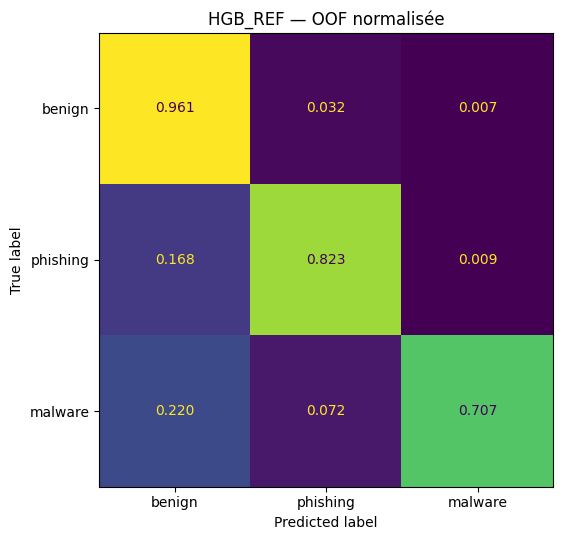

=== HGB_LEAVES_15 ===


,pred_benign,pred_phishing,pred_malware
true_benign,0.958218,0.034185,0.007597
true_phishing,0.169362,0.821530,0.009109
true_malware,0.157335,0.097643,0.745022


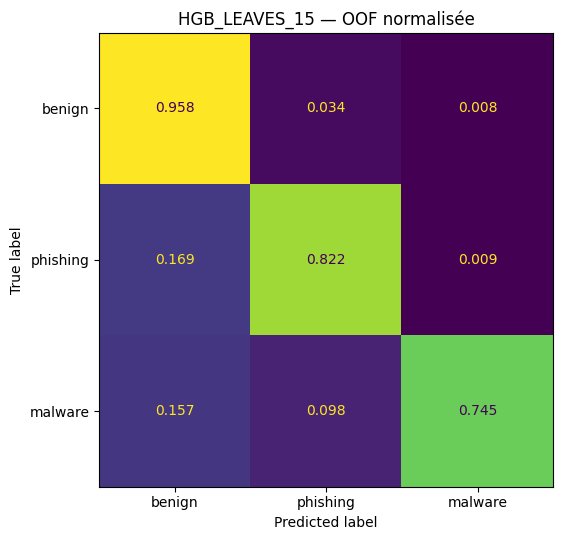

=== HGB_MINLEAF_50 ===


,pred_benign,pred_phishing,pred_malware
true_benign,0.960879,0.032061,0.007060
true_phishing,0.157217,0.834365,0.008419
true_malware,0.213285,0.064181,0.722534


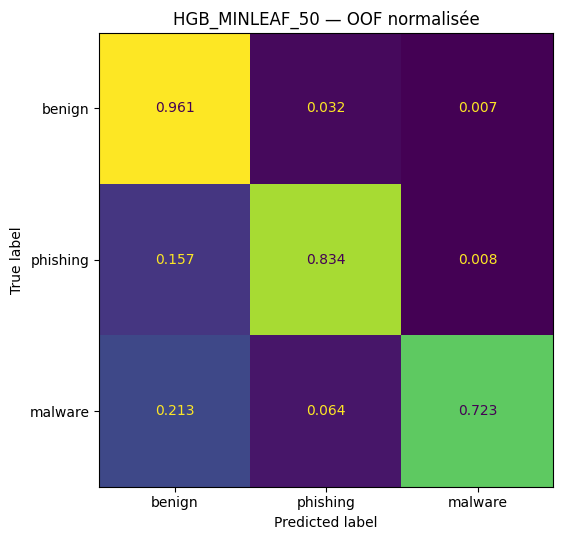

=== HGB_L2_1 ===


,pred_benign,pred_phishing,pred_malware
true_benign,0.960793,0.032640,0.006567
true_phishing,0.162323,0.826222,0.011455
true_malware,0.216403,0.086170,0.697427


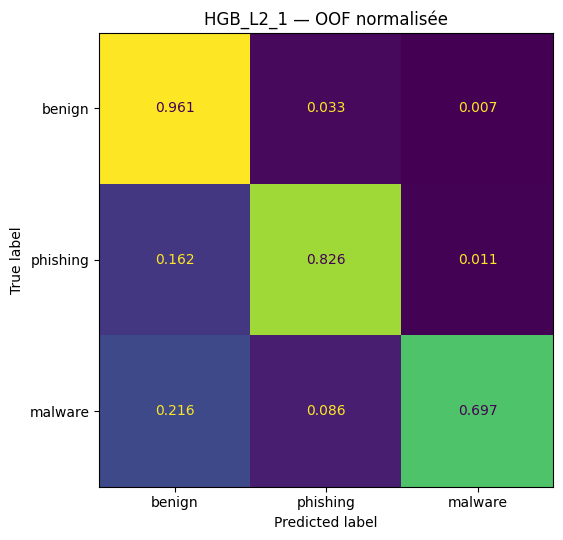

=== HGB_REG_COMBINED ===


,pred_benign,pred_phishing,pred_malware
true_benign,0.958046,0.033949,0.008004
true_phishing,0.169500,0.821185,0.009316
true_malware,0.174752,0.111859,0.713389


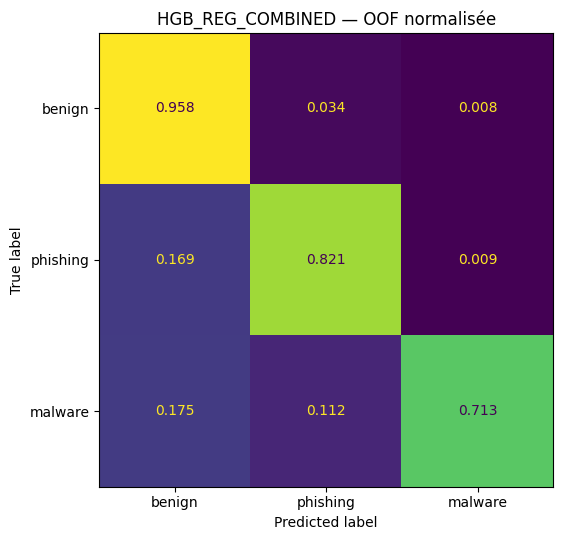

=== HGB_SLOW_005_200 ===


,pred_benign,pred_phishing,pred_malware
true_benign,0.961437,0.031825,0.006738
true_phishing,0.163174,0.827924,0.008902
true_malware,0.219562,0.083177,0.697261


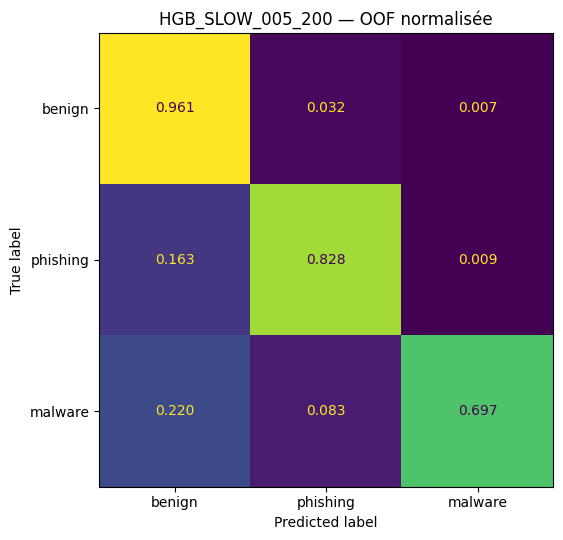

=== HGB_MALWARE_X1_25 ===


,pred_benign,pred_phishing,pred_malware
true_benign,0.960042,0.031782,0.008176
true_phishing,0.163197,0.824980,0.011823
true_malware,0.154175,0.104336,0.741489


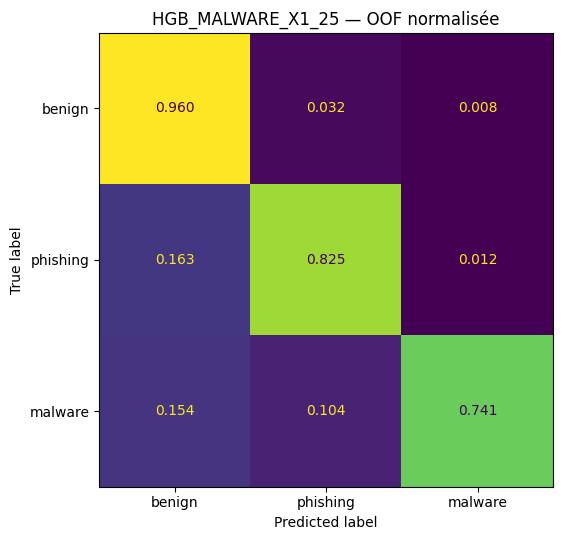

In [24]:
for config_name in (
    HGB_CONFIGS
):
    matrix = (
        oof_confusions[
            config_name
        ]
    )

    matrix_df = pd.DataFrame(
        matrix,
        index=[
            f"true_{label}"
            for label
            in LABEL_ORDER
        ],
        columns=[
            f"pred_{label}"
            for label
            in LABEL_ORDER
        ],
    )

    print(
        f"=== {config_name} ==="
    )

    display(
        matrix_df
        .round(6)
    )

    fig, ax = plt.subplots(
        figsize=(
            6.5,
            5.5,
        )
    )

    ConfusionMatrixDisplay(
        confusion_matrix=matrix,
        display_labels=LABEL_ORDER,
    ).plot(
        ax=ax,
        colorbar=False,
        values_format=".3f",
    )

    ax.set_title(
        f"{config_name} — OOF normalisée"
    )

    plt.tight_layout()
    plt.show()

# Partie IX — Deltas appariés vs HGB_REF

## 13. Effet réel de chaque modification

Chaque variante est comparée fold par fold à `HGB_REF`.

Nous ne cherchons pas seulement une moyenne supérieure :

- un delta positif sur plusieurs folds est préférable ;
- un gain malware accompagné d'une perte phishing importante doit être rejeté ;
- une réduction de variance est importante même si le gain moyen est modeste.

In [25]:
REFERENCE_CONFIG = (
    "HGB_REF"
)

delta_rows = []

for config_name in (
    HGB_CONFIGS
):
    if (
        config_name
        == REFERENCE_CONFIG
    ):
        continue

    candidate_global = (
        fold_metrics_df
        .loc[
            config_name
        ]
        .sort_index()
    )

    reference_global = (
        fold_metrics_df
        .loc[
            REFERENCE_CONFIG
        ]
        .sort_index()
    )

    candidate_phishing = (
        phishing_fold_metrics
        .loc[
            config_name
        ]
        .sort_index()
    )

    reference_phishing = (
        phishing_fold_metrics
        .loc[
            REFERENCE_CONFIG
        ]
        .sort_index()
    )

    candidate_malware = (
        malware_fold_metrics
        .loc[
            config_name
        ]
        .sort_index()
    )

    reference_malware = (
        malware_fold_metrics
        .loc[
            REFERENCE_CONFIG
        ]
        .sort_index()
    )

    for fold_id in (
        candidate_global.index
    ):
        delta_rows.append(
            {
                "configuration": config_name,
                "fold_id": int(
                    fold_id
                ),
                "delta_macro_f1": float(
                    candidate_global.loc[
                        fold_id,
                        "f1_macro",
                    ]
                    - reference_global.loc[
                        fold_id,
                        "f1_macro",
                    ]
                ),
                "delta_phishing_f1": float(
                    candidate_phishing.loc[
                        fold_id,
                        "f1",
                    ]
                    - reference_phishing.loc[
                        fold_id,
                        "f1",
                    ]
                ),
                "delta_phishing_recall": float(
                    candidate_phishing.loc[
                        fold_id,
                        "recall",
                    ]
                    - reference_phishing.loc[
                        fold_id,
                        "recall",
                    ]
                ),
                "delta_malware_f1": float(
                    candidate_malware.loc[
                        fold_id,
                        "f1",
                    ]
                    - reference_malware.loc[
                        fold_id,
                        "f1",
                    ]
                ),
                "delta_malware_recall": float(
                    candidate_malware.loc[
                        fold_id,
                        "recall",
                    ]
                    - reference_malware.loc[
                        fold_id,
                        "recall",
                    ]
                ),
            }
        )


vs_reference_deltas_df = (
    pd.DataFrame(
        delta_rows
    )
    .set_index(
        [
            "configuration",
            "fold_id",
        ]
    )
)

display(
    vs_reference_deltas_df
    .round(6)
)

delta_macro_f1  delta_phishing_f1  delta_phishing_recall  delta_malware_f1  delta_malware_recall
configuration     fold_id                                                                                                  
HGB_LEAVES_15     0             -0.004096          -0.004352              -0.003786         -0.004929             -0.004784
                  1              0.002356          -0.001994              -0.004605          0.013993              0.004633
                  2             -0.004716          -0.008802              -0.016497         -0.000018              0.007471
                  3              0.039642          -0.027714              -0.003899          0.093880              0.106955
                  4              0.002874           0.011684               0.019006         -0.007871             -0.006706
HGB_MINLEAF_50    0              0.000921           0.001323               0.001195          0.001848              0.003704
                  1              0.001250           0.001069               0.001285          0.001640              0.004633
                  2              0.013276           0.022200               0.034328          0.004280              0.006670
                  3              0.015763           0.007071               0.000093          0.035080              0.037171
                  4              0.007073           0.013748               0.020590          0.000599             -0.005216
HGB_L2_1          0             -0.000305           0.001143               0.001992         -0.001040             -0.000926
                  1              0.000852           0.000840               0.000964         -0.000065             -0.000772
                  2             -0.003774          -0.003074              -0.006308         -0.010639              0.001868
                  3             -0.012449          -0.014126              -0.002228         -0.025656             -0.026651
                  4              0.006972           0.013285               0.021085          0.000554             -0.003726
HGB_REG_COMBINED  0             -0.002778          -0.004039              -0.004184         -0.001782              0.000463
                  1              0.001567          -0.001416              -0.003106          0.011013              0.001544
                  2             -0.006227          -0.010735              -0.019408         -0.000683              0.004269
                  3              0.004284          -0.039137              -0.002971          0.015021              0.016832
                  4              0.001097           0.010504               0.017719         -0.012396             -0.008197
HGB_SLOW_005_200  0              0.000434           0.001481               0.000996          0.000396              0.000617
                  1              0.000655           0.000417               0.000107          0.000405              0.002703
                  2              0.010288           0.018611               0.031174          0.000896              0.000000
                  3             -0.012795          -0.010712              -0.000743         -0.028071             -0.029106
                  4              0.000175          -0.001880              -0.002475          0.002685             -0.001863
HGB_MALWARE_X1_25 0             -0.000785           0.000457               0.000797         -0.002870             -0.001235
                  1              0.001729          -0.000092              -0.000535          0.007297              0.000772
                  2             -0.004060          -0.003328              -0.007399         -0.012809              0.011206
                  3              0.035008          -0.030952              -0.003342          0.081228              0.092461
                  4              0.006070           0.013551               0.019798         -0.003038             -0.002235

In [26]:
vs_reference_summary = (
    vs_reference_deltas_df
    .groupby(
        level="configuration"
    )
    .agg(
        [
            "mean",
            "std",
            "min",
            "max",
        ]
    )
)

display(
    vs_reference_summary
    .round(6)
)

delta_macro_f1                               delta_phishing_f1                               delta_phishing_recall                               delta_malware_f1                                \
                            mean       std       min       max              mean       std       min       max                  mean       std       min       max             mean       std       min       max   
configuration                                                                                                                                                                                                       
HGB_L2_1               -0.001741  0.007132 -0.012449  0.006972         -0.000387  0.009833 -0.014126  0.013285              0.003101  0.010561 -0.006308  0.021085        -0.007369  0.011195 -0.025656  0.000554   
HGB_LEAVES_15           0.007212  0.018468 -0.004716  0.039642         -0.006235  0.014235 -0.027714  0.011684             -0.001956  0.012894 -0.016497  0.019006         0.019011  0.042686 -0.007871  0.093880   
HGB_MALWARE_X1_25       0.007592  0.015766 -0.004060  0.035008         -0.004073  0.016356 -0.030952  0.013551              0.001864  0.010505 -0.007399  0.019798         0.013962  0.038269 -0.012809  0.081228   
HGB_MINLEAF_50          0.007657  0.006783  0.000921  0.015763          0.009082  0.008977  0.001069  0.022200              0.011498  0.015366  0.000093  0.034328         0.008689  0.014814  0.000599  0.035080   
HGB_REG_COMBINED       -0.000411  0.004113 -0.006227  0.004284         -0.008965  0.018532 -0.039137  0.010504             -0.002390  0.013210 -0.019408  0.017719         0.002235  0.010946 -0.012396  0.015021   
HGB_SLOW_005_200       -0.000249  0.008214 -0.012795  0.010288          0.001584  0.010659 -0.010712  0.018611              0.005812  0.014236 -0.002475  0.031174        -0.004738  0.013077 -0.028071  0.002685   

                  delta_malware_recall                                
                                  mean       std       min       max  
configuration                                                         
HGB_L2_1                     -0.006041  0.011690 -0.026651  0.001868  
HGB_LEAVES_15                 0.021514  0.048141 -0.006706  0.106955  
HGB_MALWARE_X1_25             0.020194  0.040751 -0.002235  0.092461  
HGB_MINLEAF_50                0.009392  0.016183 -0.005216  0.037171  
HGB_REG_COMBINED              0.002982  0.009040 -0.008197  0.016832  
HGB_SLOW_005_200             -0.005530  0.013280 -0.029106  0.002703

# Partie X — Stabilité visuelle

## 14. Macro-F1 par fold

L'objectif est de repérer les variantes qui réduisent les chutes sur les folds difficiles.

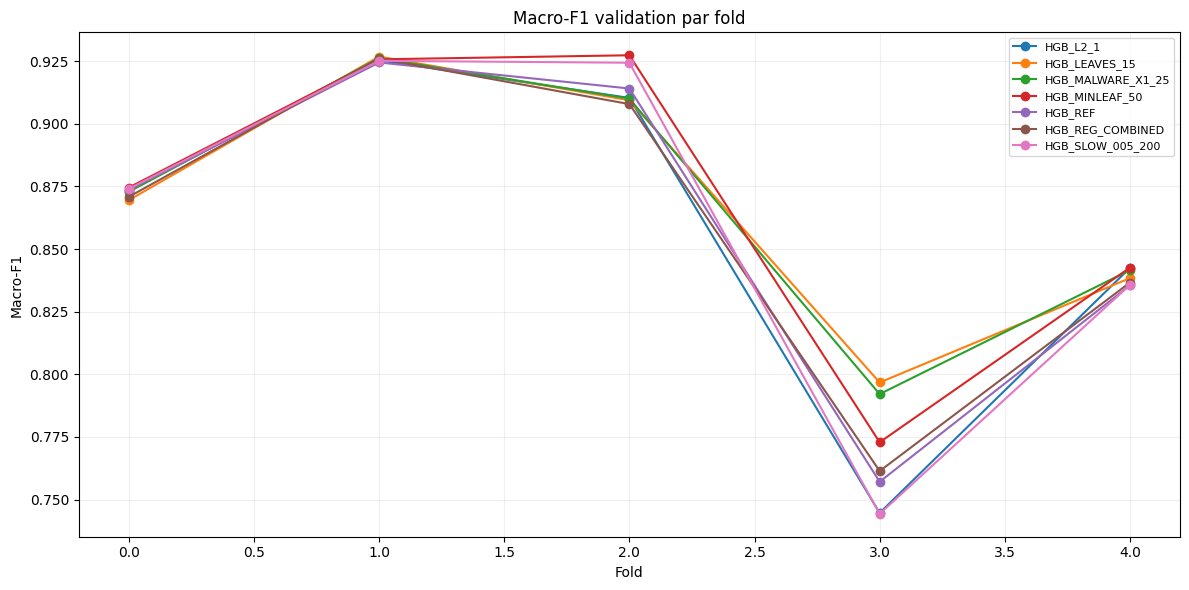

In [27]:
macro_plot_df = (
    fold_metrics_df[
        "f1_macro"
    ]
    .unstack(
        level="configuration"
    )
)

fig, ax = plt.subplots(
    figsize=(
        12,
        6,
    )
)

for column in (
    macro_plot_df.columns
):
    ax.plot(
        macro_plot_df.index,
        macro_plot_df[
            column
        ],
        marker="o",
        label=column,
    )

ax.set_title(
    "Macro-F1 validation par fold"
)
ax.set_xlabel(
    "Fold"
)
ax.set_ylabel(
    "Macro-F1"
)
ax.legend(
    fontsize=8
)
ax.grid(
    alpha=0.2
)

plt.tight_layout()
plt.show()

## 15. Recall malware par fold

C'est la visualisation la plus importante de cette phase.

Nous cherchons à augmenter le recall malware sans créer une forte instabilité.

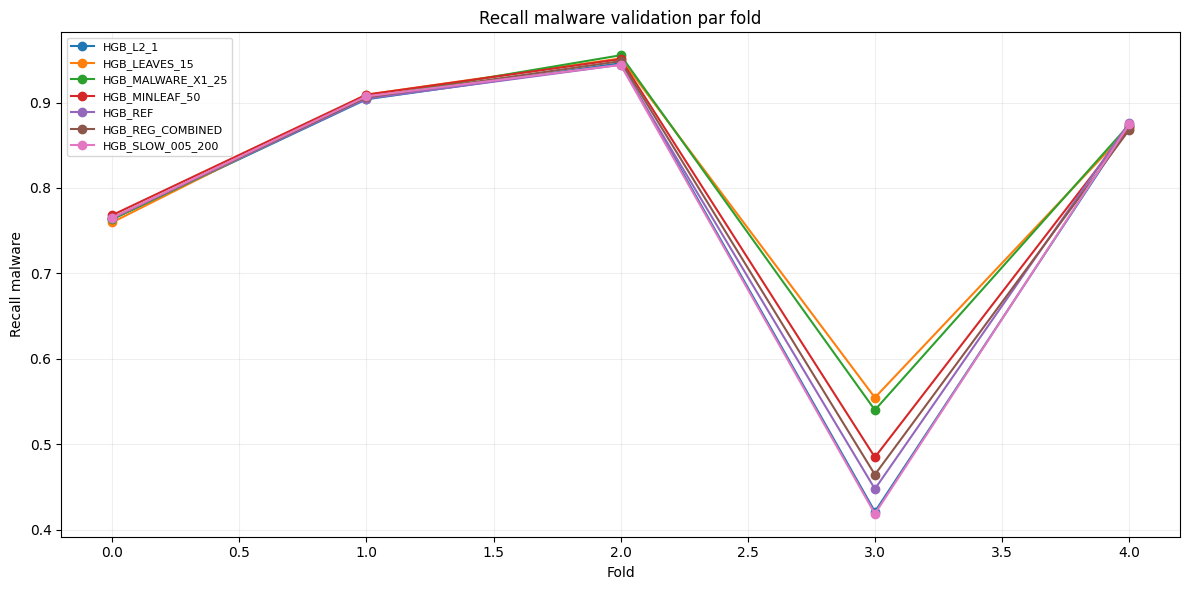

In [28]:
malware_recall_plot_df = (
    malware_fold_metrics[
        "recall"
    ]
    .unstack(
        level="configuration"
    )
)

fig, ax = plt.subplots(
    figsize=(
        12,
        6,
    )
)

for column in (
    malware_recall_plot_df.columns
):
    ax.plot(
        malware_recall_plot_df.index,
        malware_recall_plot_df[
            column
        ],
        marker="o",
        label=column,
    )

ax.set_title(
    "Recall malware validation par fold"
)
ax.set_xlabel(
    "Fold"
)
ax.set_ylabel(
    "Recall malware"
)
ax.legend(
    fontsize=8
)
ax.grid(
    alpha=0.2
)

plt.tight_layout()
plt.show()

# Partie XI — Coût

## 16. Fit et inference

Une amélioration légère n'est pas intéressante si elle dégrade fortement les performances opérationnelles.

Nous gardons les temps comme critère secondaire.

In [29]:
runtime_summary = (
    runtime_df
    .groupby(
        level="configuration"
    )
    .agg(
        {
            "fit_seconds": [
                "mean",
                "std",
                "max",
            ],
            "inference_seconds": [
                "mean",
                "std",
                "max",
            ],
            "iterations": [
                "mean",
                "max",
            ],
        }
    )
)

display(
    runtime_summary
    .round(6)
)

fit_seconds                      inference_seconds                     iterations     
                         mean       std        max              mean       std       max       mean  max
configuration                                                                                           
HGB_L2_1             4.011354  0.127918   4.126135          0.667723  0.095323  0.831275      100.0  100
HGB_LEAVES_15        4.157701  0.463257   4.621071          0.715866  0.091862  0.863789      100.0  100
HGB_MALWARE_X1_25    4.431924  0.205542   4.752306          0.686676  0.110219  0.870685      100.0  100
HGB_MINLEAF_50       4.617579  0.770689   5.739171          0.686817  0.117471  0.883623      100.0  100
HGB_REF              5.166737  1.375895   7.545131          0.723272  0.124131  0.905820      100.0  100
HGB_REG_COMBINED     3.069819  0.267788   3.490270          0.571420  0.066941  0.686558      100.0  100
HGB_SLOW_005_200     9.247418  1.743762  12.223745          1.366282  0.266381  1.823457      200.0  200

# Partie XII — Table de décision

## 17. Critères

Une nouvelle variante doit idéalement :

- conserver `macro-F1 CV ≳ 0.85` ;
- conserver `F1 phishing ≳ 0.86` ;
- garder `phishing → benign < 17 %` ;
- augmenter `recall malware` vers `0.78–0.80` si possible ;
- conserver `F1 malware ≳ 0.81` ;
- réduire ou au minimum ne pas augmenter la variance inter-folds ;
- éviter une hausse excessive du coût.

Ces seuils sont des objectifs de décision, pas des contraintes artificielles d'optimisation.

In [30]:
phishing_index = (
    LABEL_ORDER.index(
        "phishing"
    )
)

malware_index = (
    LABEL_ORDER.index(
        "malware"
    )
)

benign_index = (
    LABEL_ORDER.index(
        "benign"
    )
)

decision_rows = []

for config_name in (
    HGB_CONFIGS
):
    global_fold = (
        fold_metrics_df
        .loc[
            config_name
        ]
    )

    phishing_fold = (
        phishing_fold_metrics
        .loc[
            config_name
        ]
    )

    malware_fold = (
        malware_fold_metrics
        .loc[
            config_name
        ]
    )

    matrix = (
        oof_confusions[
            config_name
        ]
    )

    decision_rows.append(
        {
            "configuration": config_name,
            "cv_macro_f1_mean": float(
                global_fold[
                    "f1_macro"
                ].mean()
            ),
            "cv_macro_f1_std": float(
                global_fold[
                    "f1_macro"
                ].std(
                    ddof=1
                )
            ),
            "cv_macro_f1_min": float(
                global_fold[
                    "f1_macro"
                ].min()
            ),
            "cv_balanced_accuracy_mean": float(
                global_fold[
                    "balanced_accuracy"
                ].mean()
            ),
            "cv_phishing_f1_mean": float(
                phishing_fold[
                    "f1"
                ].mean()
            ),
            "cv_phishing_recall_mean": float(
                phishing_fold[
                    "recall"
                ].mean()
            ),
            "cv_malware_f1_mean": float(
                malware_fold[
                    "f1"
                ].mean()
            ),
            "cv_malware_recall_mean": float(
                malware_fold[
                    "recall"
                ].mean()
            ),
            "oof_macro_f1": float(
                oof_global_df.loc[
                    config_name,
                    "f1_macro",
                ]
            ),
            "oof_phishing_to_benign": float(
                matrix[
                    phishing_index,
                    benign_index,
                ]
            ),
            "oof_malware_to_benign": float(
                matrix[
                    malware_index,
                    benign_index,
                ]
            ),
            "oof_malware_recall": float(
                oof_class_df.loc[
                    (
                        config_name,
                        "malware",
                    ),
                    "recall",
                ]
            ),
            "oof_malware_f1": float(
                oof_class_df.loc[
                    (
                        config_name,
                        "malware",
                    ),
                    "f1",
                ]
            ),
            "oof_log_loss": float(
                oof_global_df.loc[
                    config_name,
                    "log_loss",
                ]
            ),
            "fit_seconds_mean": float(
                runtime_df
                .loc[
                    config_name,
                    "fit_seconds",
                ]
                .mean()
            ),
            "inference_seconds_mean": float(
                runtime_df
                .loc[
                    config_name,
                    "inference_seconds",
                ]
                .mean()
            ),
        }
    )


decision_table = (
    pd.DataFrame(
        decision_rows
    )
    .set_index(
        "configuration"
    )
    .sort_values(
        [
            "cv_macro_f1_mean",
            "cv_malware_recall_mean",
        ],
        ascending=[
            False,
            False,
        ],
    )
)

display(
    decision_table
    .round(6)
)

,cv_macro_f1_mean,cv_macro_f1_std,cv_macro_f1_min,cv_balanced_accuracy_mean,cv_phishing_f1_mean,cv_phishing_recall_mean,cv_malware_f1_mean,cv_malware_recall_mean,oof_macro_f1,oof_phishing_to_benign,oof_malware_to_benign,oof_malware_recall,oof_malware_f1,oof_log_loss,fit_seconds_mean,inference_seconds_mean
configuration,,,,,,,,,,,,,,,,
HGB_MINLEAF_50,0.868635,0.064429,0.772852,0.865370,0.877141,0.838357,0.858789,0.796843,0.855990,0.157217,0.213285,0.722534,0.825082,0.343766,4.617579,0.686817
HGB_MALWARE_X1_25,0.868571,0.053949,0.792097,0.865489,0.863986,0.828722,0.864061,0.807645,0.856846,0.163197,0.154175,0.741489,0.833746,0.335184,4.431924,0.686676
HGB_LEAVES_15,0.868191,0.052769,0.796730,0.864046,0.861824,0.824903,0.869110,0.808965,0.856754,0.169362,0.157335,0.745022,0.838895,0.341214,4.157701,0.715866
HGB_REF,0.860979,0.067938,0.757089,0.858426,0.868059,0.826859,0.850099,0.787451,0.847563,0.168005,0.220352,0.707362,0.814249,0.359348,5.166737,0.723272
HGB_SLOW_005_200,0.860730,0.075116,0.744293,0.858691,0.869643,0.832671,0.845361,0.781921,0.846336,0.163174,0.219562,0.697261,0.807763,0.361859,9.247418,1.366282
HGB_REG_COMBINED,0.860567,0.065290,0.761373,0.857663,0.859095,0.824469,0.852334,0.790433,0.847119,0.169500,0.174752,0.713389,0.817296,0.347738,3.069819,0.571420
HGB_L2_1,0.859238,0.071758,0.744640,0.857400,0.867673,0.829960,0.842730,0.781410,0.845192,0.162323,0.216403,0.697427,0.805879,0.359003,4.011354,0.667723


## 18. Vue par rapport aux références précédentes

Cette cellule affiche les références HGB V3 et LR-V2 uniquement pour contextualiser la décision.

Elle ne réévalue pas LR-V2.

In [31]:
reference_context = pd.DataFrame(
    {
        "HGB_V3_reference_previous": {
            "cv_macro_f1_mean": (
                HGB_REFERENCE_RESULTS[
                    "cv_macro_f1_mean"
                ]
            ),
            "cv_macro_f1_std": (
                HGB_REFERENCE_RESULTS[
                    "cv_macro_f1_std"
                ]
            ),
            "oof_macro_f1": (
                HGB_REFERENCE_RESULTS[
                    "oof_macro_f1"
                ]
            ),
            "oof_malware_recall": (
                HGB_REFERENCE_RESULTS[
                    "oof_recall_malware"
                ]
            ),
            "oof_malware_f1": (
                HGB_REFERENCE_RESULTS[
                    "oof_f1_malware"
                ]
            ),
            "oof_phishing_to_benign": (
                HGB_REFERENCE_RESULTS[
                    "oof_phishing_to_benign"
                ]
            ),
        },
        "LR_V2_previous": {
            "cv_macro_f1_mean": (
                LR_V2_REFERENCE[
                    "cv_macro_f1_mean"
                ]
            ),
            "cv_macro_f1_std": (
                LR_V2_REFERENCE[
                    "cv_macro_f1_std"
                ]
            ),
            "oof_macro_f1": (
                LR_V2_REFERENCE[
                    "oof_macro_f1"
                ]
            ),
            "oof_malware_recall": (
                LR_V2_REFERENCE[
                    "oof_recall_malware"
                ]
            ),
            "oof_malware_f1": (
                LR_V2_REFERENCE[
                    "oof_f1_malware"
                ]
            ),
            "oof_phishing_to_benign": (
                LR_V2_REFERENCE[
                    "oof_phishing_to_benign"
                ]
            ),
        },
    }
).T

display(
    reference_context
    .round(6)
)

,cv_macro_f1_mean,cv_macro_f1_std,oof_macro_f1,oof_malware_recall,oof_malware_f1,oof_phishing_to_benign
HGB_V3_reference_previous,0.860979,0.067938,0.847563,0.707362,0.814249,0.168005
LR_V2_previous,0.815393,0.027901,0.819447,0.807540,0.825925,0.181415


# Conclusion finale — Sélection et durcissement HistGradientBoosting

## 1. Objectif de cette phase

Après la comparaison contrôlée entre plusieurs familles de modèles, `HistGradientBoostingClassifier` avait été retenu comme meilleure famille non linéaire pour notre classification multiclasses :

- `benign` ;
- `phishing` ;
- `malware`.

La première configuration HGB retenue était :

`HGB_REF`

avec :

- les 13 features raw ;
- aucun `log1p` ;
- aucun scaler ;
- `learning_rate=0.1` ;
- `max_iter=100` ;
- `max_leaf_nodes=31` ;
- `min_samples_leaf=20` ;
- `l2_regularization=0.0` ;
- `class_weight="balanced"` ;
- `early_stopping=False` ;
- seed `42`.

Cette configuration avait clairement dépassé Logistic Regression V2 en performance globale et phishing.

Elle conservait cependant deux limites :

1. une variance inter-folds supérieure à LR-V2 ;
2. un recall malware insuffisant et trop de malware classés `benign`.

L'objectif du notebook de durcissement était donc :

> conserver les gains benign/phishing de HGB tout en améliorant la stabilité et la récupération de malware.

---

# 2. Protocole expérimental

Le protocole n'a pas été modifié pendant le durcissement.

Nous avons conservé :

- le même snapshot ML ;
- la même quarantaine des groupes multi-labels ;
- le même split externe 80/20 ;
- le test externe verrouillé ;
- les mêmes 5 folds internes `StratifiedGroupKFold` ;
- aucun chevauchement de `group_key` ;
- les mêmes 13 features raw ;
- le même seed `42`.

Le test externe n'a pas participé à la sélection des paramètres.

Les variantes ont donc été comparées uniquement sur la cross-validation interne group-aware et les prédictions OOF.

---

# 3. Pourquoi nous avons conservé les features raw

Le benchmark précédent avait comparé :

`HGB raw`

et :

`HGB log1p`.

Les deux représentations avaient produit des résultats identiques.

Contrairement à Logistic Regression, HistGradientBoosting n'a donc pas besoin de la transformation `log1p` pour exploiter efficacement ces variables.

La représentation définitive HGB reste :

`RAW_FEATURE_COLUMNS`

avec exactement 13 features.

Cela simplifie le pipeline d'inférence :

`URL canonique → 13 features raw → HGB`

sans :

- transformation `log1p` ;
- `StandardScaler`.

---

# 4. Variantes de durcissement testées

Nous avons volontairement limité l'expérience à sept configurations interprétables :

| Configuration | Modification principale |
|---|---|
| `HGB_REF` | référence |
| `HGB_LEAVES_15` | `max_leaf_nodes=15` |
| `HGB_MINLEAF_50` | `min_samples_leaf=50` |
| `HGB_L2_1` | `l2_regularization=1.0` |
| `HGB_REG_COMBINED` | régularisation structurelle combinée |
| `HGB_SLOW_005_200` | `learning_rate=0.05`, `max_iter=200` |
| `HGB_MALWARE_X1_25` | weighting balanced + malware ×1.25 |

L'objectif n'était pas de rechercher exhaustivement les hyperparamètres.

Chaque expérience devait répondre à une hypothèse précise.

---

# 5. Résultats de la référence HGB

La configuration de référence obtenait approximativement :

- macro-F1 CV : `0.86098` ;
- écart-type macro-F1 : `0.06794` ;
- pire fold : `0.75709` ;
- macro-F1 OOF : `0.84756`.

Elle restait très performante sur phishing, mais présentait une faiblesse malware.

En particulier :

`malware → benign ≈ 22.04 %`

était considéré trop élevé pour notre contexte Threat Intelligence.

---

# 6. Effet de `HGB_MINLEAF_50`

Cette variante augmente :

`min_samples_leaf : 20 → 50`.

Elle obtient le meilleur macro-F1 moyen parmi les variantes testées :

- macro-F1 CV : environ `0.86864` ;
- std : environ `0.06443` ;
- pire fold : environ `0.77285`.

Son principal avantage est la classe phishing.

Elle améliore le macro-F1 sur chacun des cinq folds et réduit :

`phishing → benign`

d'environ :

`16.80 % → 15.72 %`.

Cette variante montre qu'un lissage supplémentaire des feuilles améliore la généralisation phishing.

Cependant, son effet sur la faiblesse malware reste limité :

`malware → benign`

reste supérieur à environ `21 %`.

### Conclusion

`HGB_MINLEAF_50` est excellent pour phishing mais ne corrige pas suffisamment le problème malware qui motivait cette phase.

---

# 7. Effet de `HGB_LEAVES_15`

Cette variante réduit :

`max_leaf_nodes : 31 → 15`.

Elle réduit donc la complexité structurelle de chaque arbre.

Résultats principaux :

- macro-F1 CV : environ `0.86819` ;
- std : environ `0.05277` ;
- pire fold : environ `0.79673` ;
- recall malware CV : environ `0.80897`.

Elle améliore fortement la stabilité.

Elle améliore également nettement le comportement malware.

En OOF :

`malware → benign`

passe approximativement de :

`22.04 % → 15.73 %`.

C'est une amélioration importante.

Cependant :

`phishing → benign`

passe légèrement de :

`16.80 % → ~16.94 %`.

Le modèle améliore donc fortement malware mais régresse très légèrement sur notre autre classe de menace.

### Conclusion

`HGB_LEAVES_15` constitue une excellente variante de robustesse structurelle, mais pas le meilleur compromis global.

---

# 8. Effet de la régularisation L2

La configuration :

`HGB_L2_1`

n'a pas produit de gain intéressant.

Elle dégrade légèrement :

- macro-F1 ;
- F1 malware ;
- recall malware.

### Conclusion

La régularisation L2 n'est pas retenue.

Nous n'avons pas de raison d'ajouter cette complexité au modèle final.

---

# 9. Effet de la régularisation combinée

`HGB_REG_COMBINED`

combine :

- moins de feuilles ;
- feuilles plus grandes ;
- L2.

Cette combinaison n'apporte pas de gain suffisant par rapport aux modifications simples.

Elle pénalise également certaines performances phishing.

### Conclusion

La combinaison est rejetée.

Une régularisation plus complexe n'est pas justifiée.

---

# 10. Effet du learning rate réduit

La variante :

`HGB_SLOW_005_200`

utilise :

- `learning_rate=0.05` ;
- `max_iter=200`.

L'objectif était de vérifier si un apprentissage plus progressif améliorait la stabilité.

Le résultat n'apporte pas d'amélioration significative par rapport à HGB_REF.

Il augmente en revanche le temps d'entraînement.

### Conclusion

Le couple :

`learning_rate=0.1 / max_iter=100`

reste préférable.

---

# 11. Pondération malware renforcée

La dernière expérience applique :

`HGB_MALWARE_X1_25`.

Le modèle conserve les paramètres structurels de HGB_REF :

- `max_leaf_nodes=31` ;
- `min_samples_leaf=20` ;
- `learning_rate=0.1` ;
- `max_iter=100`.

La différence porte uniquement sur les poids d'entraînement.

Pour chaque fold :

1. les poids `balanced` sont calculés uniquement à partir de `y_train` ;
2. les observations malware reçoivent ensuite un multiplicateur `1.25` ;
3. la validation n'intervient jamais dans le calcul des poids.

Cette méthode permet d'augmenter modérément le coût des erreurs malware sans introduire de fuite.

---

# 12. Résultats de `HGB_MALWARE_X1_25`

Cette configuration obtient approximativement :

- macro-F1 CV : **`0.86857`** ;
- std macro-F1 : **`0.05395`** ;
- pire fold : **`0.79210`** ;
- balanced accuracy CV : **`0.86549`** ;
- F1 phishing CV : **`0.86399`** ;
- recall phishing CV : **`0.82872`** ;
- F1 malware CV : **`0.86406`** ;
- recall malware CV : **`0.80765`**.

Elle améliore simultanément :

- la performance globale ;
- la stabilité ;
- le recall malware ;
- le F1 malware ;
- le pire fold.

Par rapport à HGB_REF :

- macro-F1 : environ `+0.0076` ;
- malware F1 : environ `+0.0140` ;
- malware recall : environ `+0.0202`.

L'écart-type passe :

`0.06794 → 0.05395`.

Le pire fold passe :

`0.75709 → 0.79210`.

Le modèle devient donc sensiblement plus robuste aux groupes difficiles.

---

# 13. Résultats OOF

Les macro-F1 OOF sont approximativement :

| Configuration | Macro-F1 OOF |
|---|---:|
| HGB_REF | 0.84756 |
| HGB_MINLEAF_50 | 0.85599 |
| HGB_LEAVES_15 | 0.85675 |
| **HGB_MALWARE_X1_25** | **0.85685** |

`HGB_MALWARE_X1_25` obtient donc le meilleur macro-F1 OOF des principales variantes.

La balanced accuracy OOF progresse également par rapport à HGB_REF.

---

# 14. Amélioration des erreurs critiques

Le résultat le plus important concerne les menaces incorrectement classées benign.

## Phishing → benign

HGB_REF :

`~16.80 %`

HGB_MALWARE_X1_25 :

`~16.32 %`

La pondération malware ne détériore donc pas cette erreur critique.

Elle l'améliore légèrement.

---

## Malware → benign

HGB_REF :

`~22.04 %`

HGB_MALWARE_X1_25 :

`~15.42 %`

La réduction est d'environ :

`6.6 points de pourcentage`.

C'est une amélioration majeure.

Une partie des malware précédemment classés benign devient désormais classée phishing.

Cette erreur reste incorrecte au sens multiclasses, mais elle est opérationnellement moins dangereuse qu'un malware classé benign :

le modèle conserve alors la détection du caractère malveillant de l'URL.

---

# 15. Qualité probabiliste

La pondération malware améliore également les métriques probabilistes.

La log-loss OOF passe approximativement de :

`0.35935`

à :

`0.33518`.

Le Brier multiclasses passe approximativement de :

`0.20159`

à :

`0.19248`.

Cette amélioration indique que le durcissement n'agit pas uniquement sur les labels finaux.

La distribution probabiliste globale devient également meilleure.

Une calibration spécifique restera néanmoins nécessaire avant d'interpréter ces probabilités comme une confiance métier absolue.

---

# 16. Pourquoi `HGB_MALWARE_X1_25` est retenu

Trois configurations étaient particulièrement intéressantes :

### `HGB_MINLEAF_50`

Meilleure amélioration phishing.

### `HGB_LEAVES_15`

Très bonne stabilité et excellent recall malware.

### `HGB_MALWARE_X1_25`

Meilleur compromis entre :

- macro-F1 ;
- balanced accuracy ;
- stabilité ;
- pire fold ;
- phishing ;
- malware ;
- erreurs vers benign ;
- qualité probabiliste.

La sélection finale privilégie le comportement global de sécurité plutôt que la maximisation d'une seule métrique.

---

# 17. Configuration HGB sélectionnée

La configuration retenue devient :

# `HGB_MALWARE_X1_25`

Architecture :

```text
13 raw lexical features
        ↓
HistGradientBoostingClassifier

loss                  = log_loss
learning_rate         = 0.1
max_iter              = 100
max_leaf_nodes        = 31
min_samples_leaf      = 20
l2_regularization     = 0.0
early_stopping        = False
random_state          = 42

# Partie XIII — Entraînement et sauvegarde de HGB-V3 Hardened

La sélection des hyperparamètres est maintenant terminée.

Les modèles produits pendant la cross-validation ne doivent pas être sauvegardés comme modèle final, car chacun n'a été entraîné que sur une fraction du train externe.

Nous réentraînons donc :

`HGB_MALWARE_X1_25`

sur l'intégralité de :

`external_train_df`

soit le train externe complet.

Le test externe reste exclu de cet entraînement.

La politique de weighting finale est reconstruite uniquement à partir des labels du train complet :

1. poids multiclasses `balanced` ;
2. multiplication des poids malware par `1.25`.

Le modèle sauvegardé représente la configuration finale de la **phase de sélection ML**.

Son statut reste :

`selected_hardened_candidate`

et non `production_validated`, car les validations temporelles et inter-source restent à effectuer.

In [32]:
from __future__ import annotations

import time

import numpy as np

from dotenv import load_dotenv
from sklearn.ensemble import (
    HistGradientBoostingClassifier,
)
from sklearn.utils.class_weight import (
    compute_sample_weight,
)


load_dotenv(
    dotenv_path=PROJECT_ROOT / ".env",
    override=False,
)


FINAL_MODEL_CONFIGURATION = (
    "HGB_MALWARE_X1_25"
)

FINAL_MODEL_FEATURE_COLUMNS = list(
    RAW_FEATURE_COLUMNS
)

MALWARE_WEIGHT_MULTIPLIER = 1.25


# ============================================================
# 1. Construire X / y
# ============================================================

X_final_train = (
    external_train_df[
        FINAL_MODEL_FEATURE_COLUMNS
    ]
    .astype(float)
)

y_final_train = (
    external_train_df[
        "label_code"
    ]
    .copy()
)


if len(
    X_final_train
) != len(
    external_train_df
):
    raise RuntimeError(
        "Volume du train final incohérent."
    )


if len(
    FINAL_MODEL_FEATURE_COLUMNS
) != 13:
    raise RuntimeError(
        "Le modèle final doit utiliser "
        "exactement 13 features."
    )


if X_final_train.isna().any().any():
    raise RuntimeError(
        "NaN détecté dans le train final."
    )


if not np.isfinite(
    X_final_train.to_numpy(
        dtype=float
    )
).all():
    raise RuntimeError(
        "Valeur non finie détectée "
        "dans le train final."
    )


unexpected_labels = (
    set(
        y_final_train.unique()
    )
    - set(
        LABEL_ORDER
    )
)

if unexpected_labels:
    raise RuntimeError(
        "Labels inattendus dans le train final : "
        f"{sorted(unexpected_labels)}"
    )


# ============================================================
# 2. Recalculer les poids sur tout le train
# ============================================================

final_sample_weight = (
    compute_sample_weight(
        class_weight="balanced",
        y=y_final_train,
    )
    .astype(float)
)


malware_mask = (
    y_final_train
    .to_numpy()
    == "malware"
)

final_sample_weight[
    malware_mask
] *= MALWARE_WEIGHT_MULTIPLIER


if not np.isfinite(
    final_sample_weight
).all():
    raise RuntimeError(
        "Sample weights non finis."
    )


if np.any(
    final_sample_weight
    <= 0
):
    raise RuntimeError(
        "Sample weights non positifs."
    )


# Audit agrégé uniquement.
weight_audit = {}

for label in LABEL_ORDER:
    label_mask = (
        y_final_train
        .to_numpy()
        == label
    )

    weight_audit[
        label
    ] = {
        "rows": int(
            label_mask.sum()
        ),
        "mean_weight": float(
            final_sample_weight[
                label_mask
            ].mean()
        ),
        "min_weight": float(
            final_sample_weight[
                label_mask
            ].min()
        ),
        "max_weight": float(
            final_sample_weight[
                label_mask
            ].max()
        ),
    }


print(
    "Politique de weighting finale :"
)

for label, values in (
    weight_audit.items()
):
    print(
        label,
        values,
    )


# ============================================================
# 3. Construire le modèle final
# ============================================================

hgb_v3_hardened_model = (
    HistGradientBoostingClassifier(
        loss="log_loss",
        learning_rate=0.1,
        max_iter=100,
        max_leaf_nodes=31,
        min_samples_leaf=20,
        l2_regularization=0.0,

        # Important :
        # weighting personnalisé via sample_weight.
        class_weight=None,

        early_stopping=False,
        random_state=RANDOM_SEED,
    )
)


# ============================================================
# 4. Entraîner sur tout external_train
# ============================================================

fit_started_at = (
    time.perf_counter()
)

hgb_v3_hardened_model.fit(
    X_final_train,
    y_final_train,
    sample_weight=(
        final_sample_weight
    ),
)

final_fit_seconds = (
    time.perf_counter()
    - fit_started_at
)


print()
print(
    "✓ HGB-V3 Hardened entraîné"
)

print(
    "Training rows:",
    len(
        X_final_train
    ),
)

print(
    "Features:",
    len(
        FINAL_MODEL_FEATURE_COLUMNS
    ),
)

print(
    "Iterations:",
    hgb_v3_hardened_model.n_iter_,
)

print(
    "Fit seconds:",
    round(
        final_fit_seconds,
        4,
    ),
)

print(
    "Classes:",
    list(
        hgb_v3_hardened_model.classes_
    ),
)

Politique de weighting finale :
benign {'rows': 46599, 'mean_weight': 0.8164052161348239, 'min_weight': 0.8164052161348241, 'max_weight': 0.8164052161348241}
phishing {'rows': 43475, 'mean_weight': 0.8750699635806019, 'min_weight': 0.8750699635806019, 'max_weight': 0.8750699635806019}
malware {'rows': 24057, 'mean_weight': 1.9767461999972296, 'min_weight': 1.976746199997229, 'max_weight': 1.976746199997229}

✓ HGB-V3 Hardened entraîné
Training rows: 114131
Features: 13
Iterations: 100
Fit seconds: 18.5322
Classes: ['benign', 'malware', 'phishing']


## Sauvegarde de l'artefact

L'artefact sauvegardé contient uniquement ce qui est nécessaire à l'inférence et à la reproductibilité :

- modèle entraîné ;
- ordre exact des features ;
- labels ;
- version dataset ;
- version Feature Set ;
- politique de weighting ;
- hyperparamètres.

Aucune URL, aucun `group_key`, aucun hostname et aucun sample individuel n'est inclus dans l'artefact.

Un fichier JSON séparé contient les métadonnées lisibles.

Le fichier `.joblib` reçoit également un hash SHA-256.

### Sécurité

Les fichiers `joblib` reposent sur une sérialisation Python.

Ils ne doivent jamais être chargés depuis une source non fiable.

Seuls les artefacts produits et contrôlés par notre propre pipeline doivent être désérialisés.

In [33]:
import hashlib
import json
from datetime import (
    datetime,
    timezone,
)
from pathlib import Path

import joblib
import sklearn


MODEL_NAME = (
    "url_multiclass_hgb_v3_hardened"
)

MODEL_VERSION = (
    "hgb-v3-hardened"
)

MODEL_STATUS = (
    "selected_hardened_candidate"
)


MODEL_ARTIFACT_DIR = (
    PROJECT_ROOT
    / "artifacts"
    / "ml"
    / "models"
)

MODEL_ARTIFACT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


model_path = (
    MODEL_ARTIFACT_DIR
    / f"{MODEL_NAME}.joblib"
)

metadata_path = (
    MODEL_ARTIFACT_DIR
    / f"{MODEL_NAME}.metadata.json"
)


# ============================================================
# Métriques de sélection
# ============================================================

selected_decision = (
    decision_table.loc[
        FINAL_MODEL_CONFIGURATION
    ]
)

selected_oof_global = (
    oof_global_df.loc[
        FINAL_MODEL_CONFIGURATION
    ]
)

selected_oof_phishing = (
    oof_class_df.loc[
        (
            FINAL_MODEL_CONFIGURATION,
            "phishing",
        )
    ]
)

selected_oof_malware = (
    oof_class_df.loc[
        (
            FINAL_MODEL_CONFIGURATION,
            "malware",
        )
    ]
)


# ============================================================
# Artefact runtime
# ============================================================

artifact = {
    "artifact_version": (
        MODEL_VERSION
    ),

    "status": (
        MODEL_STATUS
    ),

    "model": (
        hgb_v3_hardened_model
    ),

    "feature_columns": list(
        FINAL_MODEL_FEATURE_COLUMNS
    ),

    "feature_representation": (
        "raw"
    ),

    "label_order": list(
        LABEL_ORDER
    ),

    "probability_label_order": list(
        PROBABILITY_LABEL_ORDER
    ),

    "model_classes": list(
        hgb_v3_hardened_model.classes_
    ),

    "dataset": {
        "name": (
            DATASET_NAME
        ),
        "version": (
            DATASET_VERSION
        ),
        "feature_set_version": (
            EXPECTED_FEATURE_SET_VERSION
        ),
    },
}


joblib.dump(
    artifact,
    model_path,
    compress=3,
)


# ============================================================
# Hash SHA-256
# ============================================================

def sha256_file(
    path: Path,
) -> str:
    digest = hashlib.sha256()

    with path.open(
        "rb"
    ) as handle:
        for chunk in iter(
            lambda: handle.read(
                1024 * 1024
            ),
            b"",
        ):
            digest.update(
                chunk
            )

    return digest.hexdigest()


model_sha256 = sha256_file(
    model_path
)


# ============================================================
# Métadonnées lisibles
# ============================================================

metadata = {
    "model_name": (
        MODEL_NAME
    ),

    "model_version": (
        MODEL_VERSION
    ),

    "status": (
        MODEL_STATUS
    ),

    "created_at_utc": (
        datetime.now(
            timezone.utc
        ).isoformat()
    ),

    "model_family": (
        "HistGradientBoostingClassifier"
    ),

    "selected_configuration": (
        FINAL_MODEL_CONFIGURATION
    ),

    "dataset": {
        "name": (
            DATASET_NAME
        ),
        "version": (
            DATASET_VERSION
        ),
        "feature_set_version": (
            EXPECTED_FEATURE_SET_VERSION
        ),
    },

    "features": {
        "representation": (
            "raw"
        ),
        "count": len(
            FINAL_MODEL_FEATURE_COLUMNS
        ),
        "columns": list(
            FINAL_MODEL_FEATURE_COLUMNS
        ),
    },

    "hyperparameters": {
        "loss": (
            "log_loss"
        ),
        "learning_rate": 0.1,
        "max_iter": 100,
        "max_leaf_nodes": 31,
        "min_samples_leaf": 20,
        "l2_regularization": 0.0,
        "class_weight": None,
        "early_stopping": False,
        "random_state": (
            RANDOM_SEED
        ),
    },

    "weighting": {
        "strategy": (
            "balanced_sample_weight"
        ),
        "malware_multiplier": (
            MALWARE_WEIGHT_MULTIPLIER
        ),
        "computed_from": (
            "external_train labels only"
        ),
        "audit": (
            weight_audit
        ),
    },

    "training": {
        "rows": int(
            len(
                X_final_train
            )
        ),
        "feature_count": int(
            len(
                FINAL_MODEL_FEATURE_COLUMNS
            )
        ),
        "fit_seconds": float(
            final_fit_seconds
        ),
        "iterations": int(
            hgb_v3_hardened_model.n_iter_
        ),
        "external_test_used_for_fit": False,
    },

    "selection_protocol": {
        "external_split": (
            "historical_80_20_locked"
        ),
        "internal_cv": (
            "StratifiedGroupKFold"
        ),
        "n_splits": (
            INTERNAL_CV_N_SPLITS
        ),
        "group_aware": True,
        "external_test_used_for_selection": False,
        "tuning_status": (
            "closed"
        ),
    },

    "validated_metrics": {
        "cv_macro_f1_mean": float(
            selected_decision[
                "cv_macro_f1_mean"
            ]
        ),

        "cv_macro_f1_std": float(
            selected_decision[
                "cv_macro_f1_std"
            ]
        ),

        "cv_macro_f1_min": float(
            selected_decision[
                "cv_macro_f1_min"
            ]
        ),

        "cv_balanced_accuracy_mean": float(
            selected_decision[
                "cv_balanced_accuracy_mean"
            ]
        ),

        "cv_phishing_f1_mean": float(
            selected_decision[
                "cv_phishing_f1_mean"
            ]
        ),

        "cv_phishing_recall_mean": float(
            selected_decision[
                "cv_phishing_recall_mean"
            ]
        ),

        "cv_malware_f1_mean": float(
            selected_decision[
                "cv_malware_f1_mean"
            ]
        ),

        "cv_malware_recall_mean": float(
            selected_decision[
                "cv_malware_recall_mean"
            ]
        ),

        "oof_macro_f1": float(
            selected_oof_global[
                "f1_macro"
            ]
        ),

        "oof_balanced_accuracy": float(
            selected_oof_global[
                "balanced_accuracy"
            ]
        ),

        "oof_log_loss": float(
            selected_oof_global[
                "log_loss"
            ]
        ),

        "oof_roc_auc_macro": float(
            selected_oof_global[
                "roc_auc_ovr_macro"
            ]
        ),

        "oof_average_precision_macro": float(
            selected_oof_global[
                "average_precision_macro"
            ]
        ),

        "oof_multiclass_brier": float(
            selected_oof_global[
                "multiclass_brier"
            ]
        ),

        "oof_phishing_precision": float(
            selected_oof_phishing[
                "precision"
            ]
        ),

        "oof_phishing_recall": float(
            selected_oof_phishing[
                "recall"
            ]
        ),

        "oof_phishing_f1": float(
            selected_oof_phishing[
                "f1"
            ]
        ),

        "oof_malware_precision": float(
            selected_oof_malware[
                "precision"
            ]
        ),

        "oof_malware_recall": float(
            selected_oof_malware[
                "recall"
            ]
        ),

        "oof_malware_f1": float(
            selected_oof_malware[
                "f1"
            ]
        ),

        "oof_phishing_to_benign": float(
            selected_decision[
                "oof_phishing_to_benign"
            ]
        ),

        "oof_malware_to_benign": float(
            selected_decision[
                "oof_malware_to_benign"
            ]
        ),
    },

    "environment": {
        "python": (
            platform.python_version()
        ),
        "scikit_learn": (
            sklearn.__version__
        ),
        "numpy": (
            np.__version__
        ),
    },

    "integrity": {
        "algorithm": (
            "sha256"
        ),
        "model_sha256": (
            model_sha256
        ),
    },

    "limitations": [
        (
            "Model selected through repeated "
            "group-aware CV analysis."
        ),
        (
            "Temporal robustness validation "
            "is still required."
        ),
        (
            "Independent-source validation "
            "is still required."
        ),
        (
            "Multi-label quarantined groups "
            "have not yet been used as stress set."
        ),
        (
            "Source-label confounding remains "
            "a known dataset limitation."
        ),
        (
            "Artifact is not yet marked "
            "production_validated."
        ),
    ],
}


with metadata_path.open(
    "w",
    encoding="utf-8",
) as handle:
    json.dump(
        metadata,
        handle,
        ensure_ascii=False,
        indent=2,
    )


print(
    "✓ Artefact écrit :",
    model_path.relative_to(
        PROJECT_ROOT
    ),
)

print(
    "✓ Metadata écrite :",
    metadata_path.relative_to(
        PROJECT_ROOT
    ),
)

print(
    "✓ SHA-256 :",
    model_sha256,
)

✓ Artefact écrit : artifacts\ml\models\url_multiclass_hgb_v3_hardened.joblib
✓ Metadata écrite : artifacts\ml\models\url_multiclass_hgb_v3_hardened.metadata.json
✓ SHA-256 : 257fe44c262c2611bf0d399a92f9beb88386479b2679d69bb3de39c354648b6a
